# SEEDS - 1 - Existing CGSs Search

This notebook combines and formalizes data to identify existing Community Growing Schemes (CGSs) in **Leeds**. 

The workflow is designed to be adaptable for any UK local authority, which is selected at the beginning of the notebook. However, as this project focuses on Leeds, several datasets are sourced from the Leeds City Council and other Leeds-based organisations, making parts of the analysis project-specific.

Where possible, the notebook automatically retrieves the most up-to-date available data. Some datasets are however static and have not been updated for several years, these must thus be dowloaded manually.



In [606]:
pip install matplotlib mapclassify geopandas numpy scipy folium plotly osmnx scikit-learn seaborn fiona openpyxl

Note: you may need to restart the kernel to use updated packages.


In [607]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import os
import hashlib
import folium
import mapclassify
import re
import fiona
import osmnx as ox
import requests
from shapely.geometry import Point, shape
import networkx as nx
from pathlib import Path

In [608]:
import sys
print(sys.executable)

c:\Users\qxnq723\Desktop\Project_2\Dashboard Development\venv\Scripts\python.exe


In [609]:
#Set to show all columns of tables
pd.set_option("display.max_columns", None)

In [610]:
#Choose Local Authority to work with
LOCAL_AUTHORITY_NAME = 'Leeds' 

output_file = f'output_{LOCAL_AUTHORITY_NAME}.gpkg'

## 1- Define Local Authority Boundaries

The UK local authorities boundaries data was downloaded from [geoportal](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-districts-may-2024-boundaries-uk-bfe-2/explore?location=53.495068%2C-0.354857%2C7).
The UK data is subsetted to only include the boundaries of the local authority chosen at the start, in the case of this study Leeds is chosen.

In [611]:
# Define data folder path
DATA_DIR = r'C:\Users\qxnq723\Desktop\Project_2\Datasets'

# UK local authorities file path
UK_LAD_PATH = f"{DATA_DIR}\Local_Authority_Districts_May_2024_Boundaries_UK_BFE_6583563793708892075\LAD_MAY_2024_UK_BFE.shp"

print(f"Configured for: {LOCAL_AUTHORITY_NAME}")
print(f"Data directory: {DATA_DIR}")

Configured for: Leeds
Data directory: C:\Users\qxnq723\Desktop\Project_2\Datasets


In [612]:
# Load UK Local Authority District boundaries
print("Loading UK Local Authority District boundaries...")
LAD_2024 = gpd.read_file(UK_LAD_PATH)

print(f"Loaded {len(LAD_2024)} local authority districts")
print(f"Available LADs include: {sorted(LAD_2024['LAD24NM'].unique())[:10]}...")

# Check if our chosen LAD exists 
if LOCAL_AUTHORITY_NAME in LAD_2024['LAD24NM'].values:
    print(f"Found {LOCAL_AUTHORITY_NAME} in the dataset")
    target_lad = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
    print(f"Area: {target_lad.to_crs('EPSG:27700').geometry.area.iloc[0]/1000000:.2f} km²")
else:
    print(f"{LOCAL_AUTHORITY_NAME} not found in dataset")
    print("Available LADs:", sorted(LAD_2024['LAD24NM'].unique()))

Loading UK Local Authority District boundaries...
Loaded 361 local authority districts
Available LADs include: ['Aberdeen City', 'Aberdeenshire', 'Adur', 'Amber Valley', 'Angus', 'Antrim and Newtownabbey', 'Ards and North Down', 'Argyll and Bute', 'Armagh City, Banbridge and Craigavon', 'Arun']...
Found Leeds in the dataset
Area: 551.70 km²


Isolate the outline of the chosen Local Authority (in this case Leeds), to clip other datasets to it.

<Axes: >

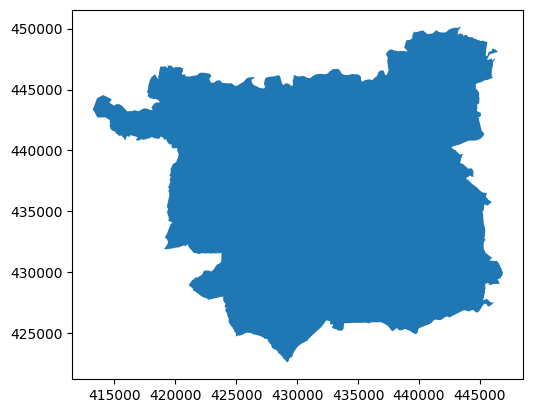

In [613]:
#Keep only chosen LA and plot it
chosen_LA = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
chosen_LA.plot()

In [614]:
#Check CRS
print(chosen_LA.crs)

EPSG:27700


In [615]:
#Create outline of chosen LA
chosen_LA['outline'] = 1
LA_outline = chosen_LA.dissolve(by= 'outline')

In [616]:
chosen_LA.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 260 to 260
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LAD24CD   1 non-null      str     
 1   LAD24NM   1 non-null      str     
 2   LAD24NMW  0 non-null      str     
 3   BNG_E     1 non-null      int64   
 4   BNG_N     1 non-null      int64   
 5   LONG      1 non-null      float64 
 6   LAT       1 non-null      float64 
 7   geometry  1 non-null      geometry
 8   outline   1 non-null      int64   
dtypes: float64(2), geometry(1), int64(3), str(3)
memory usage: 204.0 bytes


In [617]:
#Save the outline to put it on dashboard
#Save Locally
chosen_LA.to_file((os.path.join(DATA_DIR, "Leeds_boundaries.gpkg")), driver='GPKG')
#Save in workspace
workspace_path= r"C:\Users\qxnq723\Desktop\Project_2\Dashboard Development"
chosen_LA.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "Leeds_boundaries.gpkg")), driver='GPKG')

A function is created to subset datasets to the chosen local authority boundaries.

In [618]:
#Create function to subset data to the chosen LA
def subset_to_LAD(LAD_gdf, LAD_column_name, LAD_name, data_to_subset):
    """
    Subset a greenspace (or similar file) to only include greenspaces 
    within a chosen local authority.
    
    Parameters
    ----------
    LAD_gdf : geopandas.GeoDataFrame
        GeoDataFrame containing local authority district boundaries
    LAD_column_name : str
        Name of the column containing LAD names
    LAD_name : str
        Name of the specific LAD to subset to
    data_to_subset : geopandas.GeoDataFrame
        Data to be subset to the chosen LAD
        
    Returns
    -------
    geopandas.GeoDataFrame
        Data subset to only include features within the chosen LAD
    """
    chosen_LAD = LAD_gdf.loc[LAD_gdf[LAD_column_name] == LAD_name, :]
    chosen_LAD = chosen_LAD.to_crs(data_to_subset.crs)
    data_subset_to_LAD = data_to_subset[data_to_subset.within(chosen_LAD.union_all())]
    return data_subset_to_LAD

## 2- Combining OS and OSM data

This section combines OS and OSM datasets to identify existing Community Growing Schemes in Leeds. Greenspaces marked as private are excluded.

### A- Ordnance Survey (OS) Green Spaces

The Green Spaces data is downloaded from [Ordnance Survey](https://osdatahub.os.uk/data/downloads/open/OpenGreenspace).
The OS green spaces data is then subsetted to include only green spaces within the chosen local authority (here Leeds). It is then subsetted again to only include spaces that are considered to be existing CGSs.

Information about definitions of the OS green spaces functions can be found [here](https://docs.os.uk/os-downloads/products/land-and-terrain-portfolio/os-open-greenspace/os-open-greenspace-technical-specification/code-lists/functionvalue).

In [619]:
# Define path to OS green spaces data
OPGS_PATH = f"{DATA_DIR}\OS_Greenspace_UK\Data\opgrsp_gb.gpkg"

In [620]:
# Check available layers in the OS Open Greenspace file

print("Available layers in OS Open Greenspace:")
layers = fiona.listlayers(OPGS_PATH)
for layer in layers:
    print(f"  - {layer}")

Available layers in OS Open Greenspace:
  - access_point
  - greenspace_site


In [621]:
# Load OS Open Greenspace data (this loads all the data - so would not recommend visualising at this stage)
print("\nLoading OS Open Greenspace data...")
os_greenspace_access = gpd.read_file(OPGS_PATH, layer='access_point')
os_greenspace_site = gpd.read_file(OPGS_PATH, layer='greenspace_site')

print(f"Loaded {len(os_greenspace_access)} access points")
print(f"Loaded {len(os_greenspace_site)} greenspace sites")


Loading OS Open Greenspace data...
Loaded 355705 access points
Loaded 165978 greenspace sites


In [622]:
# Subset OS greenspace data to the target LAD
print(f"\nSubsetting OS greenspace data to {LOCAL_AUTHORITY_NAME}...")

greenspace_sites_lad = subset_to_LAD(
    LAD_gdf=LAD_2024, 
    LAD_column_name='LAD24NM', 
    LAD_name=LOCAL_AUTHORITY_NAME, 
    data_to_subset=os_greenspace_site
)

greenspace_access_lad = subset_to_LAD(
    LAD_gdf=LAD_2024, 
    LAD_column_name='LAD24NM', 
    LAD_name=LOCAL_AUTHORITY_NAME, 
    data_to_subset=os_greenspace_access
)

print(f"OS greenspace sites in {LOCAL_AUTHORITY_NAME}: {len(greenspace_sites_lad)}")
print(f"OS greenspace access points in {LOCAL_AUTHORITY_NAME}: {len(greenspace_access_lad)}")

# Display sample data
print("\nSample OS greenspace data:")
print(greenspace_sites_lad[['id', 'distinctive_name_1', 'function']].head())


Subsetting OS greenspace data to Leeds...
OS greenspace sites in Leeds: 1493
OS greenspace access points in Leeds: 3636

Sample OS greenspace data:
                                       id                 distinctive_name_1  \
3    49E9C763-2EBD-A491-E063-8CCAA00A0EF3                                NaN   
50   49E9C762-B904-A491-E063-8CCAA00A0EF3                                NaN   
59   49E9C762-5AEF-A491-E063-8CCAA00A0EF3  Holy Family Roman Catholic Church   
147  49E9C762-55E5-A491-E063-8CCAA00A0EF3                                NaN   
193  49E9C6EE-2D3A-A491-E063-8CCAA00A0EF3                           Low Moor   

                  function  
3             Tennis Court  
50   Other Sports Facility  
59       Religious Grounds  
147          Bowling Green  
193  Public Park Or Garden  


In [623]:
print('Total OS greenspaces in', LOCAL_AUTHORITY_NAME,':', greenspace_sites_lad['id'].nunique())

Total OS greenspaces in Leeds : 1493


In [624]:
# Greenspace in LA by type
greenspace_sites_lad['function'].value_counts()

function
Playing Field                             266
Play Space                                249
Public Park Or Garden                     227
Religious Grounds                         175
Other Sports Facility                     168
Allotments Or Community Growing Spaces    165
Bowling Green                              88
Tennis Court                               79
Cemetery                                   51
Golf Course                                25
Name: count, dtype: int64

In [625]:
#Check CRS
print(greenspace_sites_lad.crs)

EPSG:27700


In [626]:
greenspace_sites_lad.head()

,id,function,distinctive_name_1,distinctive_name_2,distinctive_name_3,distinctive_name_4,geometry
3,49E9C763-2EBD-A491-E063-8CCAA00A0EF3,Tennis Court,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((442188.77 430186.17, 442193.13..."
50,49E9C762-B904-A491-E063-8CCAA00A0EF3,Other Sports Facility,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((435216.09 432431.7, 435234.94 ..."
59,49E9C762-5AEF-A491-E063-8CCAA00A0EF3,Religious Grounds,Holy Family Roman Catholic Church,NaN,NaN,NaN,"MULTIPOLYGON (((428100.57 432878.55, 428129.35..."
147,49E9C762-55E5-A491-E063-8CCAA00A0EF3,Bowling Green,NaN,NaN,NaN,NaN,"MULTIPOLYGON (((427259.46 433695.76, 427231.4 ..."
193,49E9C6EE-2D3A-A491-E063-8CCAA00A0EF3,Public Park Or Garden,Low Moor,NaN,NaN,NaN,"MULTIPOLYGON (((427857.67 433653.59, 427826.02..."


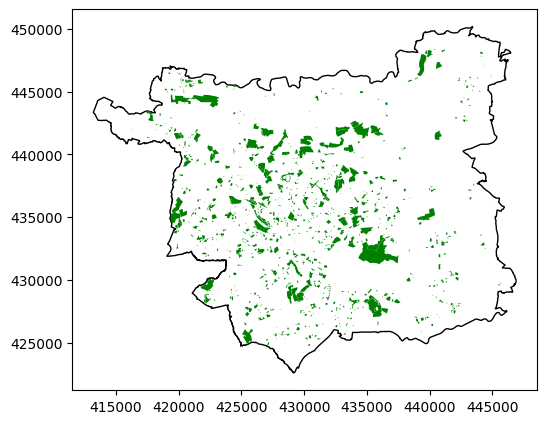

In [627]:
#Plot OS Greenspaces in Local Authority
fig , ax = plt.subplots(figsize=(6, 6))

#Plot outline first
LA_outline.plot(
    ax= ax,
    facecolor= 'none',
    edgecolor='black',
    linewidth=1
)

#Plot greenspaces
greenspace_sites_lad.plot(
    ax=ax,
    color='green'
)

plt.show()

In this section, only the OS green spaces with existing Community Growing Schemes are kept.

OS defines the 'Allotments Or Community Growing Spaces' function as: "Areas of land for growing fruit, vegetables and other plants, either in individual allotments or as a community activity. Produce is for the grower's own consumption and not primarily for commercial activity."

In [628]:
os_existing_cgs = greenspace_sites_lad[greenspace_sites_lad['function'] == 'Allotments Or Community Growing Spaces']

### B- OpenStreetMap API data

The existing CGSs data is collected from the [OpenStreetMap API](https://www.openstreetmap.org).
The map features, corresponding to existing CGSs are selected from [here](https://wiki.openstreetmap.org/wiki/Map_features).
The data is then subsetted to the chosen local authority (here Leeds).

This article is also useful: https://pythongis.org/part2/chapter-09/nb/00-retrieving-osm-data.html 

OSM Key| Value| Description
-------|----|-------
garden:type|community|Located in parks or other public spaces, community gardens are operated by an informal group of local residents. To some, community gardening is a leisurely social activity. To others, it is a response to concerns about food security.
garden:style|herb_garden|A garden used to grow herbs (spices and medical plants).
landuse|allotments|Allotment gardens (known as community gardens in the United States) are characterised by a concentration in one place of a few or up to several hundreds of land parcels that are assigned to individuals or families. In allotment gardens, the parcels are cultivated individually, contrary to community gardens where the entire area is tended collectively by a group of people
~~landuse~~|~~greenhouse_horticulture~~|~~The area of land used for growing plants in greenhouses. Buildings, water reservoirs and open areas around greenhouses used for operating the greenhouses should be considered part of such landuse.~~
landuse|orchard| Intentional planting of trees or shrubs maintained for food production, including orchards and similar plantations. Orchards usually comprise fruit or nut-producing trees grown for commercial production.
~~landuse~~|~~plant_nursery~~|~~Plant nursery grows plants (often for sale), much like a farm grows crops for food. Unlike a farm, a plant nursery generally relocates the whole of the plants they grow, as living plants, rather than only selling produce produced from them. Plants being grown can include any type of plant, from flowers to trees, including Christmas trees.~~

In [629]:
# Define OSM tags for existing CGSs

osm_tags = {
    'garden:type': ['community',
                    'herb_garden'],
    'landuse': ['allotments', 
                'orchard'
                ]
}

print("Extracting OSM CGS data...")
print(f"Tags to extract: {osm_tags}")

# Get the target LAD geometry
target_lad_geom = LAD_2024.loc[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME, :]

try:
    # Extract OSM features
    gdf = ox.features_from_polygon(
        target_lad_geom.to_crs("EPSG:4326").union_all(), 
        osm_tags
    )
    
    filters = [gdf[tag_key].isin(tag_values) 
           for tag_key, tag_values in osm_tags.items() 
           if tag_key in gdf.columns]

    osm_cgs = gdf[pd.concat(filters, axis=1).any(axis=1)].reset_index() if filters else gpd.GeoDataFrame()
    
    print(f"Extracted {len(osm_cgs)} OSM CGSs features in {LOCAL_AUTHORITY_NAME}")
    
    # Display sample data
    print("\nSample OSM CGS data:")
    available_cols = [col for col in ['name', 'leisure', 'garden:type', 'landuse', 'man_made'] if col in osm_cgs.columns]
    print(osm_cgs[available_cols].head())
    
except Exception as e:
    print(f"Error extracting OSM data: {e}")
    osm_cgs = gpd.GeoDataFrame()

Extracting OSM CGS data...
Tags to extract: {'garden:type': ['community', 'herb_garden'], 'landuse': ['allotments', 'orchard']}
Extracted 261 OSM CGSs features in Leeds

Sample OSM CGS data:
                               name leisure garden:type landuse
0      Headingley Community Orchard  garden   community     NaN
1     Wigton Moor Community Orchard  garden   community     NaN
2  Maid Marian Orchard, Copley Lane  garden   community     NaN
3                 Ouzlewell Orchard  garden   community     NaN
4      Spring Lane Sidings, Orchard  garden   community     NaN


In [630]:
osm_cgs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   element           261 non-null    str     
 1   id                261 non-null    int64   
 2   geometry          261 non-null    geometry
 3   garden:type       79 non-null     str     
 4   leisure           79 non-null     str     
 5   name              189 non-null    str     
 6   website           13 non-null     str     
 7   operator          18 non-null     str     
 8   operator:type     5 non-null      str     
 9   description       23 non-null     str     
 10  access            10 non-null     str     
 11  email             2 non-null      str     
 12  fee               5 non-null      str     
 13  note              9 non-null      str     
 14  landuse           184 non-null    str     
 15  ref:GB:uprn       28 non-null     str     
 16  source            

### C- Combining OSM and OS data

Cleaning and data prep.

In [631]:
# Tidy OS names 
os_existing_cgs['Other name(s) (OS)']= os_existing_cgs[['distinctive_name_2','distinctive_name_3','distinctive_name_4']].apply(lambda x: ', '.join(x[x.notnull()]), axis = 1).replace(r'^\s*$', np.nan, regex=True)
os_existing_cgs['Other name(s) (OS)'].unique()

<StringArray>
[nan]
Length: 1, dtype: str

In [632]:
osm_cgs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 261 entries, 0 to 260
Data columns (total 36 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   element           261 non-null    str     
 1   id                261 non-null    int64   
 2   geometry          261 non-null    geometry
 3   garden:type       79 non-null     str     
 4   leisure           79 non-null     str     
 5   name              189 non-null    str     
 6   website           13 non-null     str     
 7   operator          18 non-null     str     
 8   operator:type     5 non-null      str     
 9   description       23 non-null     str     
 10  access            10 non-null     str     
 11  email             2 non-null      str     
 12  fee               5 non-null      str     
 13  note              9 non-null      str     
 14  landuse           184 non-null    str     
 15  ref:GB:uprn       28 non-null     str     
 16  source            

In [633]:
# Clean osm data to remove green spaces/CGSs marked as private
osm_cgs = osm_cgs.loc[osm_cgs['access']!='private',:]


# Define OS 'function' equivalent for OSM data
osm_cgs['Type (OSM)'] = osm_cgs[['garden:type', 'landuse']].apply(
        lambda x: ', '.join(sorted(x.dropna().astype(str))), axis=1
    )

osm_cgs['Type (OSM)'].value_counts()

Type (OSM)
allotments            170
community              76
orchard                10
community, orchard      2
Name: count, dtype: int64

Combine data

In [634]:
# Combine OS and OSM data into one df

if len(osm_cgs) > 0:
    # Prepare OS CGS data for joining
    os_gs_to_join = os_existing_cgs[['distinctive_name_1', 'Other name(s) (OS)','function', 'id', 'geometry']].copy()
    os_gs_to_join['flag_OS'] ='OS'
    os_gs_to_join.columns = ['Name (OS)', 'Other name(s) (OS)','Type (OS)', 'OS ID', 'geometry','flag_OS']
    
    # Prepare OSM CGS data for joining
    # Combine OSM tags into one value
    osm_cgs['Type (OSM)'] = osm_cgs[['garden:type', 'landuse']].apply(
        lambda x: ', '.join(sorted(x.dropna().astype(str))), axis=1
    )

    # Select relevant columns for OSM data
    
    osm_cols = ['name', 'alt_name','Type (OSM)', 'osmid', 'geometry','flag_OSM']
    available_osm_cols = [col for col in osm_cols if col in osm_cgs.columns]
    osm_gs_to_join = osm_cgs[available_osm_cols].copy()
    osm_gs_to_join['flag_OSM'] ='OSM'
    # Ensure we have the right column names
    if 'name' in osm_gs_to_join.columns:
        osm_gs_to_join = osm_gs_to_join.rename(columns={'name': 'Name (OSM)'})
    else:
        osm_gs_to_join['Name (OSM)'] = None
        
    if 'osmid' in osm_gs_to_join.columns:
        osm_gs_to_join = osm_gs_to_join.rename(columns={'osmid': 'OSM ID'})
    else:
        osm_gs_to_join['OSM ID'] = None
    
    if 'alt_name' in osm_gs_to_join.columns:
        osm_gs_to_join = osm_gs_to_join.rename(columns={'alt_name': 'Other name(s) (OSM)'})
    else:
        osm_gs_to_join['Other name(s) (OSM)'] = None
    # Ensure both datasets have the same CRS
    osm_gs_to_join = osm_gs_to_join.to_crs(os_gs_to_join.crs)

    # Combine OS and OSM data
    print("Combining OS and OSM CGS data...")
    combined_existing_cgs = pd.concat([os_gs_to_join, osm_gs_to_join], ignore_index=True)
    
    # Create a unified flag for the data origin and remove temp flag columns 
    combined_existing_cgs['flag']= combined_existing_cgs['flag_OS'].fillna(combined_existing_cgs['flag_OSM'])
    combined_existing_cgs =combined_existing_cgs.drop(columns={'flag_OS','flag_OSM'})
    
    print(f"Combined dataset: {len(combined_existing_cgs)} features")
    print(f"  - OS features: {len(os_gs_to_join)}")
    print(f"  - OSM features: {len(osm_gs_to_join)}")
    
else:
    print("No OSM data available, using only OS data")
    combined_existing_cgs = os_gs_to_join.copy()

Combining OS and OSM CGS data...
Combined dataset: 423 features
  - OS features: 165
  - OSM features: 258


## 3- Adding Allotment data - Leeds City Council

The polygons of allotments in Leeds are scraped from the Leeds Council ArcGis webpage.

### A- Web scraping

In [635]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [636]:
url= "https://services1.arcgis.com/brSffcdOV7o1pDVT/arcgis/rest/services/Allotments/FeatureServer/1/query"
base_url = "https://services1.arcgis.com/brSffcdOV7o1pDVT/arcgis/rest/services/Allotments/FeatureServer/1"

#Get meta data
meta= requests.get(base_url, params={'f': 'json'}).json()
print(meta.keys())

headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #return all columns
    'returnGeometry': 'true', #include spatial data (polygons)
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes']
        geom = f.get('geometry')
    
        #Polygons
        if geom and 'rings' in geom:
            row['geometry_type'] = 'polygon'
            row['geometry']= shape({'type': 'Polygon', 'coordinates': geom['rings']}) #store polygon geometry
        #Polyline
        elif geom and 'paths' in geom:
            row['geometry_type'] = 'polyline'
            row['geometry']= shape({'type': 'LineString', 'coordinates': geom['paths'][0]}) #store line geometry
        #Points
        elif 'Lat' in row and 'Lon' in row:
            row['geometry_type'] = 'point'
            row['geometry'] = Point(row['Lon'], row['Lat'])
        #Fallback
        else:
            row['geometry_type'] = 'unknown'
            row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to GeoDataFrame
df = pd.DataFrame(all_rows)
LeedsCouncil_allotments = gpd.GeoDataFrame(df, geometry='geometry', crs= 'EPSG:27700')

print('Done:', len(LeedsCouncil_allotments), 'allotments in Leeds')

dict_keys(['currentVersion', 'id', 'name', 'type', 'serviceItemId', 'cacheMaxAge', 'displayField', 'description', 'copyrightText', 'defaultVisibility', 'editingInfo', 'relationships', 'isDataVersioned', 'hasContingentValuesDefinition', 'supportsAppend', 'supportsCalculate', 'supportsASyncCalculate', 'supportsTruncate', 'supportsAttachmentsByUploadId', 'supportsAttachmentsResizing', 'supportsRollbackOnFailureParameter', 'supportsStatistics', 'supportsExceedsLimitStatistics', 'supportsAdvancedQueries', 'supportsValidateSql', 'supportsCoordinatesQuantization', 'supportsLayerOverrides', 'supportsTilesAndBasicQueriesMode', 'supportsFieldDescriptionProperty', 'supportsQuantizationEditMode', 'supportsColumnStoreIndex', 'supportsApplyEditsWithGlobalIds', 'supportsMultiScaleGeometry', 'supportsReturningQueryGeometry', 'enableNullGeometry', 'hasGeometryProperties', 'geometryProperties', 'advancedQueryCapabilities', 'advancedQueryAnalyticCapabilities', 'queryBinsCapabilities', 'supportedOperation

In [637]:
#Check
LeedsCouncil_allotments.info()
print(LeedsCouncil_allotments.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 133 entries, 0 to 132
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   OBJECTID        133 non-null    int64   
 1   SITEREF         133 non-null    str     
 2   BOUNDNUM        133 non-null    str     
 3   SITEALIAS       133 non-null    str     
 4   SITESORT        133 non-null    int64   
 5   SITEADDRESS     133 non-null    str     
 6   SITEPLAN        133 non-null    str     
 7   TYPOLOGYTXT     133 non-null    str     
 8   SITEPLANPOLICY  133 non-null    str     
 9   HMCAREA         133 non-null    str     
 10  AREAHA          133 non-null    float64 
 11  PLANREFLABEL    133 non-null    str     
 12  WARD_NAME       133 non-null    str     
 13  Demand          130 non-null    float64 
 14  AG3Score        130 non-null    float64 
 15  Shape__Area     133 non-null    float64 
 16  Shape__Length   133 non-null    float64 
 17  geometry

In [638]:
LeedsCouncil_allotments.head()

,OBJECTID,SITEREF,BOUNDNUM,SITEALIAS,SITESORT,SITEADDRESS,SITEPLAN,TYPOLOGYTXT,SITEPLANPOLICY,HMCAREA,AREAHA,PLANREFLABEL,WARD_NAME,Demand,AG3Score,Shape__Area,Shape__Length,geometry_type,geometry
0,1,GRN01786,GRN017861,G1905,41905,Lydgate Place Allotments,SAP,Allotments,Policy GS1,Outer West,0.32,G1905,Calverley & Farsley,2105.348072,0.633308,3202.612701,380.540071,polygon,"POLYGON ((420311.35 437303, 420311.35 437298.6..."
1,2,GRN01590,GRN015901,G1702,41702,Pondfields Drive (East View) Allotments,SAP,Allotments,Policy GS1,Outer South East,0.92,G1702,Kippax & Methley,3934.825605,0.974207,9265.964157,428.409451,polygon,"POLYGON ((441766.9 430560.3, 441767.1 430560.2..."
2,3,GRN00122,GRN001221,G125,40125,Shafton Lane Allotments,SAP,Allotments,Policy GS1,Inner Area,1.58,G125,Beeston & Holbeck,1680.194990,3.918196,15878.601120,680.689518,polygon,"POLYGON ((428754.378 432144.598, 428618.9 4321..."
3,4,GRN01253,GRN012531,G1349,41349,Calverley Allotments,SAP,Allotments,Policy GS1,Outer West,0.50,G1349,Calverley & Farsley,2123.417028,0.981123,5031.726547,410.203203,polygon,"POLYGON ((420703.8 437200.4, 420703.3 437195.6..."
4,5,GRN01410,GRN014101,G1516,41516,Gallows Hill Allotments,SAP,Allotments,Policy GS1,Outer North West,0.22,G1516,Otley & Yeadon,1984.513056,0.461910,2206.221878,199.641861,polygon,"POLYGON ((421097.9 445873.8, 421100.7 445869.3..."


In [639]:
print(LeedsCouncil_allotments.is_valid.value_counts())
#Fix any invalid geometries
LeedsCouncil_allotments['geometry'] = LeedsCouncil_allotments.buffer(0)
print(LeedsCouncil_allotments.is_valid.value_counts())

True     129
False      4
Name: count, dtype: int64
True    133
Name: count, dtype: int64


The information about allotment contacts are also scraped from the Leeds Council ArcGis webpage

In [640]:
url= "https://services1.arcgis.com/brSffcdOV7o1pDVT/ArcGIS/rest/services/Allotments_contacts/FeatureServer/0/query"
base_url = "https://services1.arcgis.com/brSffcdOV7o1pDVT/ArcGIS/rest/services/Allotments_contacts/FeatureServer/0"

#Get meta data
meta= requests.get(base_url, params={'f': 'json'}).json()
print(meta.keys())


headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#Get meta data
meta= requests.get(url, params={'f': 'json'}).json()
print(meta.keys())

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #return all columns
    'returnGeometry': 'true', #include spatial data (polygons)
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes']
        geom = f.get('geometry')
    
        #Polygons
        if geom and 'rings' in geom:
            row['geometry_type'] = 'polygon'
            row['geometry']= shape({'type': 'Polygon', 'coordinates': geom['rings']}) #store polygon geometry
        #Polyline
        elif geom and 'paths' in geom:
            row['geometry_type'] = 'polyline'
            row['geometry']= shape({'type': 'LineString', 'coordinates': geom['paths'][0]}) #store line geometry
        #Points
        elif 'Lat' in row and 'Lon' in row:
            row['geometry_type'] = 'point'
            row['geometry'] = Point(row['Lon'], row['Lat'])
        #Fallback
        else:
            row['geometry_type'] = 'unknown'
            row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to GeoDataFrame
df = pd.DataFrame(all_rows)
allotments_contacts = gpd.GeoDataFrame(df, geometry='geometry', crs= 'EPSG:4326')
allotments_contacts = allotments_contacts.to_crs('EPSG:27700')

print('Done:', len(allotments_contacts), 'rows exported')

dict_keys(['currentVersion', 'id', 'name', 'type', 'serviceItemId', 'cacheMaxAge', 'displayField', 'description', 'copyrightText', 'defaultVisibility', 'editingInfo', 'relationships', 'isDataVersioned', 'hasContingentValuesDefinition', 'supportsAppend', 'supportsCalculate', 'supportsASyncCalculate', 'supportsTruncate', 'supportsAttachmentsByUploadId', 'supportsAttachmentsResizing', 'supportsRollbackOnFailureParameter', 'supportsStatistics', 'supportsExceedsLimitStatistics', 'supportsAdvancedQueries', 'supportsValidateSql', 'supportsCoordinatesQuantization', 'supportsLayerOverrides', 'supportsTilesAndBasicQueriesMode', 'supportsFieldDescriptionProperty', 'supportsQuantizationEditMode', 'supportsColumnStoreIndex', 'supportsApplyEditsWithGlobalIds', 'supportsReturningQueryGeometry', 'enableNullGeometry', 'advancedQueryCapabilities', 'advancedQueryAnalyticCapabilities', 'queryBinsCapabilities', 'supportedOperationsWithCollation', 'advancedEditingCapabilities', 'infoInEstimates', 'useStanda

In [641]:
#Load data
allotments_contacts.info()
print(allotments_contacts.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   FID            101 non-null    int64   
 1   Site_name      101 non-null    str     
 2   Postcode       101 non-null    str     
 3   Council_co     101 non-null    str     
 4   Contact_de     101 non-null    str     
 5   Lat            101 non-null    float64 
 6   Lon            101 non-null    float64 
 7   BNG_x          101 non-null    float64 
 8   BNG_y          101 non-null    float64 
 9   geometry_type  101 non-null    str     
 10  geometry       101 non-null    geometry
dtypes: float64(4), geometry(1), int64(1), str(5)
memory usage: 8.8 KB
EPSG:27700


In [642]:
allotments_contacts.head()

,FID,Site_name,Postcode,Council_co,Contact_de,Lat,Lon,BNG_x,BNG_y,geometry_type,geometry
0,1,Shafton Lane,LS10,Allotment association,mailto:neilcrozier1@gmail.com,53.785638,-1.566593,428653.9935,432231.4731,point,POINT (428653.708 432233.239)
1,2,Whitehouse Farm,LS10,Allotment association,mailto:allotments@leeds.gov.uk,53.768740,-1.527512,431241.4312,430367.8091,point,POINT (431241.145 430369.607)
2,3,Old Lane,LS11,Allotment association,mailto:oldlanelotts@gmail.com,53.771632,-1.566968,428638.7744,430673.0339,point,POINT (428638.495 430674.799)
3,4,Parkside Beeston,LS11,Allotment association,mailto:allotments@leeds.gov.uk,53.764568,-1.554212,429484.4391,429892.2868,point,POINT (429484.162 429894.068)
4,5,Clarkesfield,LS11,Allotment association,mailto:allotments@leeds.gov.uk,53.769477,-1.551131,429684.0971,430439.7324,point,POINT (429683.813 430441.513)


In [643]:
#Check if geometries are valid
print(allotments_contacts.is_valid.value_counts())

True    101
Name: count, dtype: int64


The allotment information is added to Leeds Council allotment polygons.

In [644]:
# Match points within allotment polygons
matches = gpd.sjoin(allotments_contacts,
                  LeedsCouncil_allotments,
                  how= 'left',
                  predicate= 'within')

# Handle unmatched points
unmatched = matches[matches['index_right'].isna()].copy()

#Find nearest polygon within 50m distance
nearest = gpd.sjoin_nearest(
    unmatched.drop(columns=['index_right']),
    LeedsCouncil_allotments,
    how='left',
    max_distance= 50,
    distance_col= 'distance'
)

#Keep sucessful direct matches
matched = matches[matches['index_right'].notna()]

#Combine the matches (inside or near allotment polygons)
all_matches = pd.concat([matched, nearest], ignore_index=True)
print(len(all_matches), 'allotment info matched')

#Attach the contact info back to their associated allotment polygons

#Keep contact info
contact_cols = ['Contact_de', 'Council_co', 'index_right']
contact_info = all_matches[contact_cols]
#Avoid duplicates
contact_info = contact_info.sort_values('index_right').drop_duplicates(subset='index_right')

LC_allotments = LeedsCouncil_allotments.merge(
    contact_info,
    left_index= True,
    right_on='index_right',
    how='left'
)

#check
print(len(LC_allotments), 'Leeds City Council allotments')

101 allotment info matched
133 Leeds City Council allotments


### B- Combining CGSs (OS + OSM) data with Leeds City Council Allotments data

In [645]:
# Combine Leeds Council allotemnts with OS and OSM data into one df

if len(LC_allotments) > 0:
    # Prepare LCC data for joining
    lc_allot_to_join = LC_allotments[['SITEREF', 'SITEADDRESS',  'TYPOLOGYTXT', 'Council_co', 'Contact_de', 'geometry']].copy()
    lc_allot_to_join['flag_LCC'] = 'LCC'
    lc_allot_to_join.columns = ['SITEREF', 'SITEADDRESS',  'TYPOLOGYTXT', 'Council_co', 'Contact_de', 'geometry', 'flag_LCC']

    # Rename columns
    lc_allot_to_join = lc_allot_to_join.rename(columns={'SITEADDRESS': 'Name (LCC)'})
    lc_allot_to_join = lc_allot_to_join.rename(columns={'TYPOLOGYTXT': 'Type (LCC)'})
    lc_allot_to_join = lc_allot_to_join.rename(columns={'SITEREF': 'LCC ID'})
    lc_allot_to_join = lc_allot_to_join.rename(columns={'Council_co': 'Management (LCC)'})
    lc_allot_to_join = lc_allot_to_join.rename(columns={'Contact_de': 'Email (LCC)'})
    #Reorder columns
    lc_allot_to_join= lc_allot_to_join[['Name (LCC)', 'Type (LCC)', 'LCC ID', 'Management (LCC)', 'Email (LCC)', 'geometry', 'flag_LCC']]

    # Ensure both datasets have the same CRS
    lc_allot_to_join= lc_allot_to_join.to_crs(combined_existing_cgs.crs)

    # Combine OS+OSM data with LCC data
    print("Combining CGS data (OS and OSM) with Leeds City Council allotments...")
    combined_exist_cgs = pd.concat([lc_allot_to_join, combined_existing_cgs], ignore_index=True)
    
    # Create a unified flag for the data origin and remove temp flag columns 
    combined_exist_cgs['flag_bis']= combined_exist_cgs['flag'].fillna(combined_exist_cgs['flag_LCC'])
    combined_exist_cgs = combined_exist_cgs.drop(columns={'flag','flag_LCC'})
    combined_exist_cgs = combined_exist_cgs.rename(columns={'flag_bis': 'flag'})
    
    print(f"Combined dataset: {len(combined_exist_cgs)} features")
    print(f"  - LCC features: {len(lc_allot_to_join)}")
    
else:
    print("No LCC data available, using only OS ans OSM data")
    combined_exist_cgs = combined_existing_cgs.copy()

Combining CGS data (OS and OSM) with Leeds City Council allotments...
Combined dataset: 556 features
  - LCC features: 133


In [646]:
combined_exist_cgs.head()

,Name (LCC),Type (LCC),LCC ID,Management (LCC),Email (LCC),geometry,Name (OS),Other name(s) (OS),Type (OS),OS ID,Name (OSM),Other name(s) (OSM),Type (OSM),OSM ID,flag
0,Lydgate Place Allotments,Allotments,GRN01786,NaN,NaN,"POLYGON ((420311.35 437303, 420311.35 437298.6...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCC
1,Pondfields Drive (East View) Allotments,Allotments,GRN01590,NaN,NaN,"POLYGON ((441766.9 430560.3, 441767.1 430560.2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCC
2,Shafton Lane Allotments,Allotments,GRN00122,Allotment association,mailto:neilcrozier1@gmail.com,"POLYGON ((428754.378 432144.598, 428618.9 4321...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCC
3,Calverley Allotments,Allotments,GRN01253,NaN,NaN,"POLYGON ((420703.8 437200.4, 420703.3 437195.6...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCC
4,Gallows Hill Allotments,Allotments,GRN01410,NaN,NaN,"POLYGON ((421097.9 445873.8, 421100.7 445869.3...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LCC


In [647]:
# Note lots of overlapping between the three datasets / diagreement on boundaries 
combined_exist_cgs.explore('flag', tooltip=['Type (OS)','Type (OSM)', 'Type (LCC)'], alpha=0.5)

The OS data seem to be in general the largest polygons, thus in the case of geometries overlapping, the OS geometry must be kept in priority (while keeping OSM/LCC information if there is any).

### C- Avoiding duplicates/ geometries overlapping

Some CGSs have overlapping geometries between OS, OSM and LCC. To avoid duplicates in the CGSs data, overlapping polygons are combined to only show the OS geometry (or OSM as fallback).

In [648]:
pip install networkx

Note: you may need to restart the kernel to use updated packages.


In [649]:
#Find overlapping geometries between OS, OSM and LCC
#Create spatial connectivity graph

#Create spatial index
sindex = combined_exist_cgs.sindex

#Create empty network graph
# each polygon = a node
# overlaps/intersections = edges
G = nx.Graph()

#Add all rows as nodes
G.add_nodes_from(combined_exist_cgs.index)

#Find intersecting polygons
#Loop through each polygon in dataset
for idx, geom in combined_exist_cgs.geometry.items():
    #Find potential matches using spatial index = find polygons near in bounding box
    #this avoids checking against all polygons (time and energy consuming)
    potential = list(sindex.intersection(geom.bounds))
    #Now find if nearby polygons are intersecting or not
    matches = combined_exist_cgs.iloc[potential]
    matches= matches[matches.geometry.intersects(geom)]
    
    #Loop though all polygons truly intersecting current polygon
    for match_idx in matches.index:
        #Avoid self intersection
        if idx != match_idx:
            #Create connection between intersecting polygons
            G.add_edge(idx, match_idx)

In [650]:
#Create clusters
# by finding connected groups of nodes in graph G

clusters = list(nx.connected_components(G))

#Store row index and cluster id
cluster_map= {}

#Assign cluster ID to each polygon
for cluster_id, component in enumerate(clusters):
    for idx in component:
        cluster_map[idx] = cluster_id

combined_exist_cgs['cluster'] = combined_exist_cgs.index.map(cluster_map)

In [651]:
#Spatially match the allotments between OS, OSM and LCC
#By grouping rows by cluster (previously created)

#Create merge flags function (provenance tracking)
def merge_flags(series):
    return '_'.join(sorted(set(series.dropna())))

#---------------------------------------------------------------

#Group by cluster and aggregate their attributes (no geometry here)
agg = combined_exist_cgs.groupby('cluster').agg({
    'Name (LCC)': 'first',
    'Type (LCC)': 'first',
    'LCC ID': 'first',
    'Management (LCC)': 'first',
    'Email (LCC)': 'first',
    
    'Name (OS)': 'first',
    'Other name(s) (OS)': 'first',
    'Type (OS)': 'first',
    'OS ID': 'first',
    
    'Name (OSM)': 'first',	
    'Other name(s) (OSM)': 'first',
    'Type (OSM)': 'first',
    'OSM ID': 'first',
    
    'flag': merge_flags, 
}).reset_index()

In [652]:
#Create geometry selection function
# OS geometry takes priority
# if OS not present, OSM takes priority

def pick_geometry(group):
    
    flags= merge_flags(group['flag'])
    
    #1- OS always takes priority
    if 'OS' in flags.split('_'):
        os_rows = group[group['flag'] == 'OS']
        if len(os_rows) > 0:
            return os_rows.iloc[0].geometry
    
    #2- OSM fallback
    if 'OSM' in flags.split('_'):
        osm_rows = group[group['flag'] == 'OSM']
        if len(osm_rows) > 0:
            return osm_rows.iloc[0].geometry
    
    #Final fallback
    return group.iloc[0].geometry

#----------------------------------------------------------------

#Apply the geometry selection per cluster
geom = (combined_exist_cgs
        .groupby('cluster')
        .apply(pick_geometry)
        .reset_index())

#Retain only cluster ID and geometries
geom.columns= ['cluster', 'geometry']

#--------------------------------------------------------------

#Merge attributes and geometry based on clusters
final = agg.merge(geom, on='cluster')

final_exist_CGS = gpd.GeoDataFrame(
    final, 
    geometry='geometry', 
    crs= combined_exist_cgs.crs)

#Check
final_exist_CGS.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 264 entries, 0 to 263
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   cluster              264 non-null    int64   
 1   Name (LCC)           126 non-null    str     
 2   Type (LCC)           126 non-null    str     
 3   LCC ID               126 non-null    str     
 4   Management (LCC)     80 non-null     str     
 5   Email (LCC)          80 non-null     str     
 6   Name (OS)            104 non-null    str     
 7   Other name(s) (OS)   0 non-null      str     
 8   Type (OS)            156 non-null    str     
 9   OS ID                156 non-null    str     
 10  Name (OSM)           179 non-null    str     
 11  Other name(s) (OSM)  1 non-null      str     
 12  Type (OSM)           239 non-null    str     
 13  OSM ID               0 non-null      object  
 14  flag                 264 non-null    str     
 15  geometry       

In [653]:
final_exist_CGS['flag'].value_counts()

flag
LCC_OS_OSM    109
OSM            95
OS_OSM         33
LCC            11
OS             10
LCC_OS          4
LCC_OSM         2
Name: count, dtype: int64

So there were 109 CGSs in common between OS, OSM and LCC.

In [654]:
#Check rows where the same CGS was in OS, OSM and LCC
#Check information was retained in each column
triple_cgs = final_exist_CGS[final_exist_CGS['flag'] == 'LCC_OS_OSM']
triple_cgs.head()

,cluster,Name (LCC),Type (LCC),LCC ID,Management (LCC),Email (LCC),Name (OS),Other name(s) (OS),Type (OS),OS ID,Name (OSM),Other name(s) (OSM),Type (OSM),OSM ID,flag,geometry
1,1,Pondfields Drive (East View) Allotments,Allotments,GRN01590,NaN,NaN,Pondfields Drive Allotments,NaN,Allotments Or Community Growing Spaces,49E9C763-2C5C-A491-E063-8CCAA00A0EF3,NaN,NaN,allotments,None,LCC_OS_OSM,"MULTIPOLYGON (((441675.4 430602.7, 441689.1 43..."
2,2,Shafton Lane Allotments,Allotments,GRN00122,Allotment association,mailto:neilcrozier1@gmail.com,Shafton Lane Allotments,NaN,Allotments Or Community Growing Spaces,49E9C762-6CC0-A491-E063-8CCAA00A0EF3,Shafton Lane Allotments,NaN,allotments,None,LCC_OS_OSM,"MULTIPOLYGON (((428651.73 432238.5, 428597.35 ..."
4,4,Gallows Hill Allotments,Allotments,GRN01410,NaN,NaN,White Bridge Allotments,NaN,Allotments Or Community Growing Spaces,49E9C73B-2E4B-A491-E063-8CCAA00A0EF3,White Bridge Allotments,NaN,allotments,None,LCC_OS_OSM,"MULTIPOLYGON (((420859.32 446068.64, 420860.83..."
5,5,North Park Avenue Allotments,Allotments,GRN00473,Allotment association,mailto:allotments@leeds.gov.uk,North Park Avenue Allotments,NaN,Allotments Or Community Growing Spaces,49E9C761-F50E-A491-E063-8CCAA00A0EF3,Lidgett Lane Allotments,NaN,allotments,None,LCC_OS_OSM,"MULTIPOLYGON (((431555.32 438072.23, 431548.38..."
6,6,Beechwood Crescent Allotments,Allotments,GRN00139,NaN,NaN,NaN,NaN,Allotments Or Community Growing Spaces,49E9C762-2D69-A491-E063-8CCAA00A0EF3,Burley Model Allotments,NaN,allotments,None,LCC_OS_OSM,"MULTIPOLYGON (((427551.25 435404.14, 427579.5 ..."


In [655]:
triple_cgs['Type (OSM)'].value_counts()
#these triplets are either community growing spaces (2) or allotments (107)

Type (OSM)
allotments    107
community       2
Name: count, dtype: int64

In [656]:
final_exist_CGS['Type (OS)'].value_counts()
#OSM has 157 allotments
#OS has 156 allotments
#LCC has 126 allotments

Type (OS)
Allotments Or Community Growing Spaces    156
Name: count, dtype: int64

In [657]:
#Visualize the cleaned dataset of existing CGSs
#There shouldn't be any overlappin polygons now
final_exist_CGS.explore('flag', tooltip=['Type (OS)','Type (OSM)', 'Type (LCC)'], alpha=0.5)

## 4- Adding LGAP Data

### A-Web Scraping

The locations of [Leeds Green Activity Provider (LGAP)](https://lgap.co.uk/find-an-activity) are scraped from their [ArcGis Online feature layer](https://www.arcgis.com/apps/mapviewer/index.html?layers=6afec02763ab4f87887939ed4d073c70). Only the activities linked to gardening are kept.

In [658]:
url= "https://services1.arcgis.com/ENz4NUfCPx4lwh83/arcgis/rest/services/Green_activities_for_LGAP_map_view/FeatureServer/0/query"
base_url = "https://services1.arcgis.com/ENz4NUfCPx4lwh83/arcgis/rest/services/Green_activities_for_LGAP_map_view/FeatureServer/0"

#Get meta data
meta= requests.get(base_url, params={'f': 'json'}).json()
print(meta.keys())


headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#Get meta data
meta= requests.get(url, params={'f': 'json'}).json()
print(meta.keys())

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #return all columns
    'returnGeometry': 'true', #include spatial data (polygons/points)
    'outSR': 4326,
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes'].copy()
        geom = f.get('geometry')
    
        #Polygons
        if geom and 'rings' in geom:
            row['geometry_type'] = 'polygon'
            row['geometry']= shape({'type': 'Polygon', 'coordinates': geom['rings']}) #store polygon geometry
        #Polyline
        elif geom and 'paths' in geom:
            row['geometry_type'] = 'polyline'
            row['geometry']= shape({'type': 'LineString', 'coordinates': geom['paths'][0]}) #store line geometry
        #Points
        elif geom and 'x' in geom and 'y' in geom:
            row['geometry_type'] = 'point'
            row['geometry'] = Point(geom['x'], geom['y'])
        #Fallback
        else:
            row['geometry_type'] = 'unknown'
            row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to GeoDataFrame
df = pd.DataFrame(all_rows)
lgap = gpd.GeoDataFrame(df, geometry='geometry', crs= 'EPSG:4326')

#Convert crs
lgap = lgap.to_crs('EPSG:27700')

print('Done:', len(lgap), 'rows exported')

dict_keys(['currentVersion', 'id', 'name', 'type', 'serviceItemId', 'cacheMaxAge', 'isView', 'isUpdatableView', 'sourceSchemaChangesAllowed', 'displayField', 'description', 'copyrightText', 'defaultVisibility', 'ownershipBasedAccessControlForFeatures', 'editFieldsInfo', 'editingInfo', 'relationships', 'isDataVersioned', 'hasContingentValuesDefinition', 'supportsAppend', 'supportsCalculate', 'supportsASyncCalculate', 'supportsTruncate', 'supportsAttachmentsByUploadId', 'supportsAttachmentsResizing', 'supportsRollbackOnFailureParameter', 'supportsStatistics', 'supportsExceedsLimitStatistics', 'supportsAdvancedQueries', 'supportsValidateSql', 'supportsCoordinatesQuantization', 'supportsLayerOverrides', 'supportsTilesAndBasicQueriesMode', 'supportsFieldDescriptionProperty', 'supportsQuantizationEditMode', 'supportsColumnStoreIndex', 'supportsApplyEditsWithGlobalIds', 'supportsReturningQueryGeometry', 'enableNullGeometry', 'supportsOBACForAnonymousUsers', 'advancedQueryCapabilities', 'advan

In [659]:
print(lgap.is_valid.value_counts())

True    87
Name: count, dtype: int64


In [660]:
#Check
lgap.info()
print(lgap.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 87 entries, 0 to 86
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   objectid                 87 non-null     int64   
 1   globalid                 87 non-null     str     
 2   organisation             87 non-null     str     
 3   organisation_other       33 non-null     str     
 4   group_name               87 non-null     str     
 5   activity_desc            84 non-null     str     
 6   activity_category        87 non-null     str     
 7   activity_category_other  3 non-null      str     
 8   prof_vol                 87 non-null     str     
 9   location                 87 non-null     str     
 10  postcode                 87 non-null     str     
 11  day_time                 87 non-null     str     
 12  ongoing_or_program       87 non-null     str     
 13  date_of_program          4 non-null      str     
 14  all_

In [661]:
#Retain only LGAP data points that have been accepted as valid
lgap = lgap[lgap['Accept'] == 'Yes']

In [662]:
lgap['Accept'].value_counts()

Accept
Yes    87
Name: count, dtype: int64

In [663]:
lgap.head()

,objectid,globalid,organisation,organisation_other,group_name,activity_desc,activity_category,activity_category_other,prof_vol,location,postcode,day_time,ongoing_or_program,date_of_program,all_year,seasonal_details,one_location,site_accessibility,toilets,indoor_space,indoor_type,indoor_other,transport_support,contact_name,phone_number,email,website_link,survey_date,CreationDate,Creator,EditDate,Editor,Accept,linkenqform,geometry_type,geometry
0,1,7528e0cb-8efc-4d44-9b78-d3c90f93b4cc,Friends of Gledhow Valley Woods,NaN,Gledhow Valley Woods Action Morning,"A monthly working party doing planting, pathwo...",Gardening,NaN,Volunteer,Meet at junction of Gledhow Lane and Gledhow V...,"LS8 4DQ, GBR",Sunday (once a month) morning,Ongoing,NaN,All year round,NaN,Yes,Not,No,No,NaN,NaN,No,David Miles,NaN,domiles54@gmail.com,https://www.facebook.com/profile.php?id=100080...,NaN,1693669061676,RuthLGAP,1694542068431,RuthLGAP,Yes,NaN,point,POINT (431864.606 436712.501)
1,2,aab02d25-788e-44d1-be06-aa46df8a5e67,Groundwork Yorkshire,NaN,Wellness Walks,Join us for a monthly walk around Ardsley Rese...,Walking Group,NaN,Professional,Ardsley Reservoir,"WF3 1EE, GBR",Last Thursday of the month afternoon,Ongoing,until Apr 23,Seasonal,Until April 2023,No,Partially,No,No,NaN,NaN,No,Ian Johnson,07730 765552,Ian.johnson@groundwork.org.uk,NaN,NaN,1693669061676,RuthLGAP,1705580667726,RuthLGAP,Yes,NaN,point,POINT (428615.015 425082.392)
2,3,f305abc4-4045-4aec-b5ce-90872a9bb01b,Groundwork Yorkshire,NaN,Allotment group,We are at the allotment every Tuesday - apart ...,Gardening,NaN,Professional,Lady Pit Lane Allotments,"LS11 6HB, GBR",Tuesday morning and afternoon,Ongoing,NaN,All year round,NaN,Yes,Partially,Yes not disabled,Yes,other,polytunnel and brick building with tables/chairs,No,Louise Ross,07730 765551,Louise.Ross@groundwork.org.uk,NaN,NaN,1693669061676,RuthLGAP,1705581267042,RuthLGAP,Yes,NaN,point,POINT (429977.064 431289.308)
3,4,a488975e-ef39-45c1-afec-27fc61fa76e3,Groundwork Yorkshire,NaN,The Morley Shed,Come to our fully-equipped wood workshop for a...,Woodworking and Natural Crafts,NaN,Professional,"Groundwork Environment & Business Centre, Morley","LS27 9SL, GBR",Mon - Fri all day,Ongoing,NaN,All year round,NaN,Yes,Partially,Yes not disabled,Yes,warm,NaN,No,Ally Speller,07971 842732,allison.speller@groundwork.org.uk,NaN,NaN,1693669061676,RuthLGAP,1694542068431,RuthLGAP,Yes,NaN,point,POINT (426387.947 427655.105)
4,5,fab88c12-10dc-4eee-a74a-b40c00e22d07,Groundwork Yorkshire,NaN,Groundwork Learning Centre,NaN,Nature-based Training Courses,NaN,Professional,"Groundwork Environment & Business Centre, Morley","LS27 9SL, GBR",Mon- Fri all day,Programs,NaN,All year round,NaN,Yes,Partially,Yes not disabled,Yes,warm,NaN,No,NaN,07730 765564,skills@groundwork.org.uk,https://groundworklearningcentre.com/,NaN,1693669061676,RuthLGAP,1694542068431,RuthLGAP,Yes,NaN,point,POINT (426387.947 427655.105)


In [664]:
lgap['activity_category'].value_counts()

activity_category
Gardening                         46
Practical Conservation            13
Walking Group                     11
Other Outdoor Activity             8
other                              4
Nature-based Training Courses      3
Woodworking and Natural Crafts     1
Gardening and Animal Care          1
Name: count, dtype: int64

In [665]:
lgap['activity_category_other'].value_counts()

activity_category_other
Farm-Scale Vegetable Growing                                                      1
DIY, maintenance and construction                                                 1
Building community in the neighbourhood through the medium of fruit tree care     1
Name: count, dtype: int64

In [666]:
#Retain only activities linked to gardening and CGS
keep1= ['Gardening', 'Gardening and Animal Care']
lgap_cgs = lgap[lgap['activity_category'].isin(keep1)]
keep2= ['Farm-Scale Vegetable Growing', 'Building community in the neighbourhood through the medium of fruit tree care']
other_cat = lgap[lgap['activity_category_other'].isin(keep2)]
#Combine
lgap_cgs = pd.concat([lgap_cgs, other_cat])

In [667]:
lgap_cgs.head()

,objectid,globalid,organisation,organisation_other,group_name,activity_desc,activity_category,activity_category_other,prof_vol,location,postcode,day_time,ongoing_or_program,date_of_program,all_year,seasonal_details,one_location,site_accessibility,toilets,indoor_space,indoor_type,indoor_other,transport_support,contact_name,phone_number,email,website_link,survey_date,CreationDate,Creator,EditDate,Editor,Accept,linkenqform,geometry_type,geometry
0,1,7528e0cb-8efc-4d44-9b78-d3c90f93b4cc,Friends of Gledhow Valley Woods,NaN,Gledhow Valley Woods Action Morning,"A monthly working party doing planting, pathwo...",Gardening,NaN,Volunteer,Meet at junction of Gledhow Lane and Gledhow V...,"LS8 4DQ, GBR",Sunday (once a month) morning,Ongoing,NaN,All year round,NaN,Yes,Not,No,No,NaN,NaN,No,David Miles,NaN,domiles54@gmail.com,https://www.facebook.com/profile.php?id=100080...,NaN,1693669061676,RuthLGAP,1694542068431,RuthLGAP,Yes,NaN,point,POINT (431864.606 436712.501)
2,3,f305abc4-4045-4aec-b5ce-90872a9bb01b,Groundwork Yorkshire,NaN,Allotment group,We are at the allotment every Tuesday - apart ...,Gardening,NaN,Professional,Lady Pit Lane Allotments,"LS11 6HB, GBR",Tuesday morning and afternoon,Ongoing,NaN,All year round,NaN,Yes,Partially,Yes not disabled,Yes,other,polytunnel and brick building with tables/chairs,No,Louise Ross,07730 765551,Louise.Ross@groundwork.org.uk,NaN,NaN,1693669061676,RuthLGAP,1705581267042,RuthLGAP,Yes,NaN,point,POINT (429977.064 431289.308)
5,6,2808b484-d486-42f7-9a58-cfd85a36906c,Mafwa Theatre,NaN,Lincoln Greeners Gardening Group,"Join to learn new skills, make friends, transf...",Gardening,NaN,Professional,"Roxby Close, Lincoln Green","LS9 7LR, GBR",Tuesday morning,Ongoing,NaN,All year round,weekly March to September and monthly October ...,Yes,Partially,No,No,NaN,NaN,Yes,"Matilya (Session Facilitator), Keziah, Tamsin",Keziah 07563 477 133 Tamsin 07593 299 298,NaN,https://www.facebook.com/mafwatheatre,NaN,1693669061676,RuthLGAP,1705338782817,RuthLGAP,Yes,NaN,point,POINT (431405.504 434198.173)
6,7,f1e095d7-378b-48e1-b091-07806d0e5674,Space2,NaN,Gipton Growers,"Dig, sow, grow, plant, eat, make, build, laugh...",Gardening,NaN,Professional,"Space2, The Old Fire Station","LS9 6NL, GBR",Tuesday afternoon,Ongoing,NaN,All year round,NaN,Yes,Partially,Yes disabled,Yes,warm,NaN,NaN,Camille Thomas,07519 042680,Camillet@space2.org.uk,https://www.facebook.com/space2community,NaN,1693669061676,RuthLGAP,1705502544208,RuthLGAP,Yes,NaN,point,POINT (433414.634 434154.19)
8,13,4d9dd267-fd5e-4ad9-94e5-d3115229ed8b,Season Well,NaN,Food Garden,"We inspire and enable people to grow, cook and...",Gardening,NaN,Professional,Guiseley,"LS20 8LZ, GBR",TBA,Programs,Contact leader to find out about future sessions.,Seasonal,TBA,Yes,Partially,Yes not disabled,No,NaN,NaN,No,Becky Mears/ Viv Hargreaves,07591965071,Becky@seasonwell.co.uk,https://www.facebook.com/seasonaleating,NaN,1693669061676,RuthLGAP,1782298838738,RuthLGAP,Yes,NaN,point,POINT (418284.839 442426.707)


In [668]:
lgap_cgs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 48 entries, 0 to 65
Data columns (total 36 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   objectid                 48 non-null     int64   
 1   globalid                 48 non-null     str     
 2   organisation             48 non-null     str     
 3   organisation_other       16 non-null     str     
 4   group_name               48 non-null     str     
 5   activity_desc            46 non-null     str     
 6   activity_category        48 non-null     str     
 7   activity_category_other  1 non-null      str     
 8   prof_vol                 48 non-null     str     
 9   location                 48 non-null     str     
 10  postcode                 48 non-null     str     
 11  day_time                 48 non-null     str     
 12  ongoing_or_program       48 non-null     str     
 13  date_of_program          1 non-null      str     
 14  all_year 

In [669]:
#Replace activity_category with activity_category_other when it is something else than gardening
lgap_cgs.loc[lgap_cgs['activity_category'] == 'other', 'activity_category'] = lgap_cgs['activity_category_other']

In [670]:
lgap_cgs['activity_category'].value_counts()

activity_category
Gardening                       46
Gardening and Animal Care        1
Farm-Scale Vegetable Growing     1
Name: count, dtype: int64

In [671]:
#Replace organisation with organisation_other when it is something else than suggested options
lgap_cgs.loc[lgap_cgs['organisation'] == 'other', 'organisation'] = lgap_cgs['organisation_other']

<Axes: >

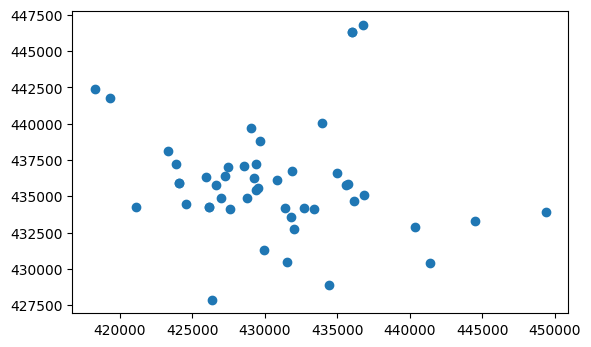

In [672]:
lgap_cgs.plot()

### B- Combining data

The LGAP data is combined with other existing CGSs data.

In [673]:
# Combine LGAP data with OS, OSM, LCC data into one df

if len(lgap_cgs) > 0:
    # Prepare LCC data for joining
    lgap_cgs_to_join = lgap_cgs[['globalid', 
                                 'organisation',
                                 'prof_vol', 
                                 'group_name',
                                 'activity_category',
                                 'activity_desc',
                                 'location',
                                 'day_time',
                                 'ongoing_or_program',
                                 'all_year',
                                 'seasonal_details',
                                 'one_location',
                                 'site_accessibility',
                                 'toilets',
                                 'indoor_space',
                                 'indoor_type',
                                 'indoor_other',
                                 'transport_support',
                                 'contact_name',
                                 'phone_number',
                                 'email',
                                 'website_link',
                                 'geometry']].copy()
    lgap_cgs_to_join['flag_LGAP'] = 'LGAP'
    lgap_cgs_to_join.columns = ['globalid', 
                                 'organisation',
                                 'prof_vol', 
                                 'group_name',
                                 'activity_category',
                                 'activity_desc',
                                 'location',
                                 'day_time',
                                 'ongoing_or_program',
                                 'all_year',
                                 'seasonal_details',
                                 'one_location',
                                 'site_accessibility',
                                 'toilets',
                                 'indoor_space',
                                 'indoor_type',
                                 'indoor_other',
                                 'transport_support',
                                 'contact_name',
                                 'phone_number',
                                 'email',
                                 'website_link',
                                 'geometry',
                                 'flag_LGAP']
    
    # Rename columns
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'group_name': 'Name (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'activity_category': 'Type (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'globalid': 'LGAP ID'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'organisation': 'Organisation (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'prof_vol': 'Management (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'activity_desc': 'Activity Description (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'location': 'Location Description (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'day_time': 'Day and Time (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'ongoing_or_program': 'Ongoing or set programs? (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'all_year': 'All year or seasonal? (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'seasonal_details': 'Seasonal details (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'one_location': 'one_location (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'site_accessibility': 'Site Accessibility (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'toilets': 'Toilets (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'indoor_space': 'Indoor Space (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'indoor_type': 'Indoor Type (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'transport_support': 'Transport Support (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'contact_name': 'Contact name (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'phone_number': 'Phone Number (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'email': 'Email (LGAP)'})
    lgap_cgs_to_join = lgap_cgs_to_join.rename(columns={'website_link': 'Website Link (LGAP)'})
    #Create column
    
    #Reorder columns
    lgap_cgs_to_join= lgap_cgs_to_join[['Name (LGAP)', 
                                        'Type (LGAP)', 
                                        'LGAP ID', 
                                        'Management (LGAP)',
                                        'Organisation (LGAP)',
                                        'Activity Description (LGAP)',
                                        'Location Description (LGAP)',
                                        'Day and Time (LGAP)',
                                        'Ongoing or set programs? (LGAP)',
                                        'All year or seasonal? (LGAP)',
                                        'Seasonal details (LGAP)',
                                        'one_location (LGAP)',
                                        'Site Accessibility (LGAP)',
                                        'Toilets (LGAP)',
                                        'Indoor Space (LGAP)',
                                        'Indoor Type (LGAP)',
                                        'Transport Support (LGAP)',
                                        'Contact name (LGAP)',
                                        'Phone Number (LGAP)',
                                        'Email (LGAP)',
                                        'Website Link (LGAP)',
                                        'geometry',
                                        'flag_LGAP']]

    # Ensure both datasets have the same CRS
    lgap_cgs_to_join= lgap_cgs_to_join.to_crs(final_exist_CGS.crs)

    # Combine LGAP data with OS+OSM+LCC data
    print("Combining LGAP data with CGSs...")
    Existing_CGSs = pd.concat([lgap_cgs_to_join, final_exist_CGS], ignore_index=True)
    
    # Create a unified flag for the data origin and remove temp flag columns 
    Existing_CGSs['flag_bis']= Existing_CGSs['flag'].fillna(Existing_CGSs['flag_LGAP'])
    Existing_CGSs = Existing_CGSs.drop(columns={'flag','flag_LGAP'})
    Existing_CGSs = Existing_CGSs.rename(columns={'flag_bis': 'flag'})
    
    print(f"Combined dataset: {len(Existing_CGSs)} features")
    print(f"  - LGAP features: {len(lgap_cgs_to_join)}")
    
else:
    print("No LGAP data available, using only OS, OSM and LCC data")
    Existing_CGSs = final_exist_CGS.copy()

Combining LGAP data with CGSs...
Combined dataset: 312 features
  - LGAP features: 48


## 5- Adding Fruit Works Co-operative Orchard data

This orchard data was provided by the [Fruit Works Co-operative](https://www.fruitworks.org.uk/) in Leeds. As the orchard data only contains postcodes, the [Ordnance Survey CodePointOpen](https://osdatahub.os.uk/data/downloads/open/CodePointOpen) dataset is used to geocode the postcodes.

### A- Formating data

In [674]:
FWC_path = f"{DATA_DIR}\Fruit_Works_Co\community orchards list.xlsx"
FWC = pd.read_excel(FWC_path)
FWC.info()

<class 'pandas.DataFrame'>
RangeIndex: 102 entries, 0 to 101
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Unnamed: 0  102 non-null    str  
 1   Postcode    97 non-null     str  
 2   W3W centre  88 non-null     str  
 3   Ward        99 non-null     str  
 4   Access      93 non-null     str  
dtypes: str(5)
memory usage: 4.1 KB


In [675]:
FWC['Postcode'].count()
#Expect to be able to map 86 orchards, others dont have postcodes and cannot be located

np.int64(97)

In [676]:
codepo_path = f"{DATA_DIR}\OS_codepo_gpkg_gb\Data\codepo_gb.gpkg"
codepo = gpd.read_file(codepo_path)
codepo.head()

,postcode,positional_quality_indicator,country_code,nhs_regional_ha_code,nhs_ha_code,admin_county_code,admin_district_code,admin_ward_code,geometry
0,AB10 1AB,10,S92000003,NaN,S08000020,NaN,S12000033,S13002842,POINT (394235 806529)
1,AB10 1AF,10,S92000003,NaN,S08000020,NaN,S12000033,S13002842,POINT (394235 806529)
2,AB10 1AG,10,S92000003,NaN,S08000020,NaN,S12000033,S13002842,POINT (394230 806469)
3,AB10 1AH,10,S92000003,NaN,S08000020,NaN,S12000033,S13002842,POINT (394235 806529)
4,AB10 1AL,10,S92000003,NaN,S08000020,NaN,S12000033,S13002842,POINT (394333 806529)


In [677]:
cols = ['postcode', 'geometry']
codepo = codepo[cols]
codepo = codepo.rename(columns={'postcode': 'Postcode'})

In [678]:
#Associated a geometry to each orchard using the postcode
FWC = FWC.merge(
    codepo,
    on='Postcode'
)
#Convert to GeoDataFrame
FWC = gpd.GeoDataFrame(FWC, geometry='geometry', crs='EPSG:27700')

FWC.head()

,Unnamed: 0,Postcode,W3W centre,Ward,Access,geometry
0,"Maid Marian orchard, Copley Lane",WF3 3AA,https://what3words.com/landed.holly.awards,Ardsley and Robin Hood,by arrangement,POINT (432623 427515)
1,Ouzlewell Orchard,WF3 3QP,https://what3words.com/wires.emerge.decay,Ardsley and Robin Hood,open,POINT (433850 426273)
2,Spring Lane Sidings,WF3 2BB,https://what3words.com/port.safely.damage,Ardsley and Robin Hood,open,POINT (430847 425482)
3,Beeston Hill,LS11 8LH,https://what3words.com/tins.legend.lazy,Beeston and Holbeck,open,POINT (429365 431422)
4,Cottingley x 3,LS11 0JT,https://what3words.com/monday.maple.held,Beeston and Holbeck,open,POINT (427370 430227)


In [679]:
FWC['Access'].value_counts()

Access
open              67
during the day     5
by arrangement     3
ticketed entry     2
for residents      1
Name: count, dtype: int64

In [680]:
FWC['geometry'].isna().sum()

np.int64(0)

In [681]:
FWC.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 86 entries, 0 to 85
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   Unnamed: 0  86 non-null     str     
 1   Postcode    86 non-null     str     
 2   W3W centre  76 non-null     str     
 3   Ward        86 non-null     str     
 4   Access      78 non-null     str     
 5   geometry    86 non-null     geometry
dtypes: geometry(1), str(5)
memory usage: 4.2 KB


### B- Combining data

In [682]:
# Combine orchard data with other data into one df

if len(FWC) > 0:
    # Prepare FWC data for joining
    FWC_to_join = FWC[['Unnamed: 0', 'Postcode', 'Access' , 'geometry']].copy()
    FWC_to_join['flag_FWC'] = 'FWC'
    FWC_to_join.columns = ['Unnamed: 0', 'Postcode', 'Access' , 'geometry', 'flag_FWC']

    # Rename columns
    FWC_to_join = FWC_to_join.rename(columns={'Unnamed: 0': 'Name (FWC)'})
    FWC_to_join = FWC_to_join.rename(columns={'Access': 'Access (FWC)'})
    FWC_to_join = FWC_to_join.rename(columns={'Postcode': 'Postcode (FWC)'})
    FWC_to_join['Type (FWC)'] = 'Orchard'

    #Reorder columns
    FWC_to_join= FWC_to_join[['Name (FWC)', 'Type (FWC)',  'Postcode (FWC)', 'Access (FWC)', 'geometry', 'flag_FWC']]

    # Ensure both datasets have the same CRS
    FWC_to_join= FWC_to_join.to_crs(Existing_CGSs.crs)

    # Combine data with FWC data
    print("Combining FWC data with other CGSs...")
    Existing_CGSs = pd.concat([FWC_to_join, Existing_CGSs], ignore_index=True)
    
    # Create a unified flag for the data origin and remove temp flag columns 
    Existing_CGSs['flag_bis']= Existing_CGSs['flag'].fillna(Existing_CGSs['flag_FWC'])
    Existing_CGSs = Existing_CGSs.drop(columns={'flag','flag_FWC'})
    Existing_CGSs = Existing_CGSs.rename(columns={'flag_bis': 'flag'})
    
    print(f"Combined dataset: {len(Existing_CGSs)} features")
    print(f"  - FWC features: {len(FWC_to_join)}")
    
else:
    print("No FWC data available")
    Existing_CGSs = Existing_CGSs.copy()

Combining FWC data with other CGSs...
Combined dataset: 398 features
  - FWC features: 86


In [683]:
Existing_CGSs.head()

,Name (FWC),Type (FWC),Postcode (FWC),Access (FWC),geometry,Name (LGAP),Type (LGAP),LGAP ID,Management (LGAP),Organisation (LGAP),Activity Description (LGAP),Location Description (LGAP),Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Contact name (LGAP),Phone Number (LGAP),Email (LGAP),Website Link (LGAP),cluster,Name (LCC),Type (LCC),LCC ID,Management (LCC),Email (LCC),Name (OS),Other name(s) (OS),Type (OS),OS ID,Name (OSM),Other name(s) (OSM),Type (OSM),OSM ID,flag
0,"Maid Marian orchard, Copley Lane",Orchard,WF3 3AA,by arrangement,POINT (432623 427515),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWC
1,Ouzlewell Orchard,Orchard,WF3 3QP,open,POINT (433850 426273),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWC
2,Spring Lane Sidings,Orchard,WF3 2BB,open,POINT (430847 425482),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWC
3,Beeston Hill,Orchard,LS11 8LH,open,POINT (429365 431422),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWC
4,Cottingley x 3,Orchard,LS11 0JT,open,POINT (427370 430227),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWC


## ~~6-Adding Feed Leeds/Urbal Map Data~~
**This section was removed as the Feed Leeds data is outdated and/or is not data that should be integrated into the SEEDS dashboard.**

Different datasets related to existing CGSs from the Urbal map are integrate:
* Bee Hives
* Community Growing Projects
* ~~Community Harvest~~ geometry not valid
* ~~Composting Sites~~ geometry not valid
* ~~Council Allotments~~ geometry not valid
* Edible Gardens (accessible)
* Edible Gardens (contact)
* Farm Visits
* ~~Food for Life Schools~~ not included
* Fruit and Nut Trees
* Green Groups Locations
* ~~LCC Sustainable Schools~~ not included
* LEC Food Patches
* Orchards and Forest Gardens
* ~~Other Allotments~~ geometry not valid
* Parks containing Edible Beds
* ~~Public Harvest~~ geometry not valid
* Resources (compost tools etc)
* Schools who Grow Food
* Schools with livestock
* Veg Growing

### A- Formating Data

In [684]:
# #The map layers useful to identify existing CGS have been isolated in a folder
# #files are loaded from this folder only if their geometries are valid
# #all the files have the same column structure and can thus be concatenated into a single gdf

# folder= Path(DATA_DIR)/"Urbal_Map_Layers_CGS"
# gdfs= []

# for file in folder.glob("*.kml"):
#     try:
#         gdf= gpd.read_file(file, driver="KML")
#         #Add file name as Type column
#         file_name= re.sub(r"[^\w]+", "_", file.stem).strip("_")
#         gdf['Type']= file_name
#         gdfs.append(gdf)
#         print(f'Loaded: {file.name}')
#     except Exception as e:
#         print(f'Skipped: {file.name} ({e})')

# Urbal_data = gpd.GeoDataFrame(
#     pd.concat(gdfs, ignore_index=True),
#     crs=gdfs[0].crs if gdfs else None
# )

In [685]:
# Urbal_data.info()

In [686]:
# #Keep only non-empty columns/ columns with useful info
# Urbal_data= Urbal_data[['Type', 'Name', 'description', 'geometry']]
# Urbal_data.head()

In [687]:
# #The website links are extracted from the descrition column into a 'Website Link (Urbal)' column
# # extract() extracts single link per cell
# # https?:// matches htpp and htpps
# # \S+ keeps going until whitespace
# Urbal_data['Website Link (Urbal)']= Urbal_data['description'].str.extract(r"(https?://\S+)", expand=False)
# #And remove URLs from the description column
# Urbal_data['description'] = (
#     Urbal_data['description']
#     .str.replace(r"https?://\S+", "", regex=True)
#     .str.strip() #remove spaces at start and end of info
#     .str.replace(r"</?b>", "", regex=True)
#     .str.replace(r"\s+", " ", regex=True) #remove whitespace
# )
# #And remove URLs from the name column
# Urbal_data['Name'] = (
#     Urbal_data['Name']
#     .str.replace(r"https?://\S+", "", regex=True)
#     .str.strip() #remove spaces at start and end of info
#     .str.replace(r"</?b>", "", regex=True)
#     .str.replace(r"\s+", " ", regex=True) #remove whitespace
# )
# Urbal_data.head()

In [688]:
# Urbal_data['description'].unique()

In [689]:
# Urbal_data['Type'].value_counts()

### B- Combining Data

In [690]:
# Existing_CGSs.columns

In [691]:
# # Combine Urbal data with other data into one df

# if len(Urbal_data) > 0:
#     # Prepare Urbal data for joining
#     Urbal_to_join = Urbal_data[['Type', 'Name', 'description', 'geometry', 'Website Link (Urbal)']].copy()
#     Urbal_to_join['flag_Urbal'] = 'Urbal'
#     Urbal_to_join.columns = ['Type', 'Name', 'description', 'geometry', 'Website Link (Urbal)', 'flag_Urbal']

#     # Rename columns
#     Urbal_to_join = Urbal_to_join.rename(columns={'Type': 'Type (Urbal)'})
#     Urbal_to_join = Urbal_to_join.rename(columns={'Name': 'Name (Urbal)'})
#     Urbal_to_join = Urbal_to_join.rename(columns={'description': 'Description (Urbal)'})

#     #Reorder columns
#     Urbal_to_join= Urbal_to_join[['flag_Urbal', 'Type (Urbal)', 'Name (Urbal)', 'geometry', 'Description (Urbal)', 'Website Link (Urbal)']]

#     # Ensure both datasets have the same CRS
#     Urbal_to_join= Urbal_to_join.to_crs(Existing_CGSs.crs)

#     # Combine data with Urbal data
#     print("Combining Urbal data with other CGSs...")
#     Existing_CGSs = pd.concat([Urbal_to_join, Existing_CGSs], ignore_index=True)
    
#     # Create a unified flag for the data origin and remove temp flag columns 
#     Existing_CGSs['flag_bis']= Existing_CGSs['flag'].fillna(Existing_CGSs['flag_Urbal'])
#     Existing_CGSs = Existing_CGSs.drop(columns={'flag','flag_Urbal'})
#     Existing_CGSs = Existing_CGSs.rename(columns={'flag_bis': 'flag'})
    
#     print(f"Combined dataset: {len(Existing_CGSs)} features")
#     print(f"  - Urbal features: {len(Urbal_to_join)}")
    
# else:
#     print("No Urbal data available")
#     Existing_CGSs = Existing_CGSs.copy()

In [692]:
# Existing_CGSs.head()

## 7- Adding FoodWiseLeeds Composting Sites

### Loading and Formating Data

In [693]:
compost_path = f"{DATA_DIR}\Composting_Sites_data.xlsx"
compost = pd.read_excel(compost_path)
compost.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Name                  10 non-null     str  
 1   Organisation          8 non-null      str  
 2   Activity_Description  2 non-null      str  
 3   Postcode              10 non-null     str  
 4   Location_Description  10 non-null     str  
 5   Contact_name          8 non-null      str  
 6   Email                 9 non-null      str  
 7   Website Link          1 non-null      str  
dtypes: str(8)
memory usage: 772.0 bytes


In [694]:
#Associated a geometry to each composting collective site using the postcode
compost = compost.merge(
    codepo,
    on='Postcode'
)
#Convert to GeoDataFrame
compost  = gpd.GeoDataFrame(compost, geometry='geometry', crs='EPSG:27700')

compost.head()

,Name,Organisation,Activity_Description,Postcode,Location_Description,Contact_name,Email,Website Link,geometry
0,Chapel Allerton Composting in the Park,NaN,NaN,LS7 4QN,"Chapel Allerton Park, Woodland Crescent LS7 4QN",Annie Whitehead OR Lukas and Katie at The Frui...,anniewhiteheadLeeds@gmail.com | Katy.daniel@ho...,NaN,POINT (430790 437434)
1,The Involve Centre,The Involve Centre,NaN,LS10 2QE,"Whitfield Avenue, Hunslet, LEEDS LS10 2QE",Annie Whitehead,anniewhiteheadLeeds@gmail.com |Penny@Involve.o...,NaN,POINT (431182 431633)
2,Friends of Hunslet Moor,Friends of Hunslet Moor Hub,NaN,LS11 5FN,"Hunslet Moor Park, Moor Road, Leeds, LS11 5FN",Sam Gilmore,Sgilmore51@icloud.com,NaN,POINT (430294 431776)
3,The Welcome In,OPAL (Older People's Active Learning Centre).,Now intergenerational with a toddler group.,LS16 6DJ,"55 Bedford Drive Tinshill, Leeds LS16 6DJ",Ellen Stoker,Ellen@opal-project.org.uk,NaN,POINT (425220 439259)
4,Garforth,Incredible Edible,NaN,LS25 1PP,Oak Grove Leeds LS25 1PP,Jacky Simpson,jacquelinesimpson@btinternet.com,NaN,POINT (441097 433203)


In [695]:
compost.columns


Index(['Name', 'Organisation', 'Activity_Description', 'Postcode',
       'Location_Description', 'Contact_name', 'Email', 'Website Link',
       'geometry'],
      dtype='str')

### B- Combining data

In [696]:
# Combine composting data with other data into one df

if len(compost) > 0:
    # Prepare data for joining
    compost_to_join = compost[['Name', 'Organisation', 'Activity_Description','Location_Description', 'Contact_name', 'Email', 'Website Link','geometry']].copy()
    compost_to_join['flag_FWL'] = 'FWL'
    compost_to_join.columns = ['Name', 'Organisation', 'Activity_Description','Location_Description', 'Contact_name', 'Email', 'Website Link','geometry', 'flag_FWL']

    # Rename columns
    compost_to_join = compost_to_join.rename(columns={'Name': 'Name (FWL)'})
    compost_to_join = compost_to_join.rename(columns={'Organisation': 'Organisation (FWL)'})
    compost_to_join = compost_to_join.rename(columns={'Activity_Description': 'Activity_Description (FWL)'})
    compost_to_join = compost_to_join.rename(columns={'Location_Description': 'Location_Description (FWL)'})
    compost_to_join = compost_to_join.rename(columns={'Contact_name': 'Contact_name (FWL)'})
    compost_to_join = compost_to_join.rename(columns={'Email': 'Email (FWL)'})
    compost_to_join = compost_to_join.rename(columns={'Website Link': 'Website Link (FWL)'})
    compost_to_join['Type (FWL)'] = 'Composting Collective'

    #Reorder columns
    compost_to_join= compost_to_join[['Name (FWL)', 
                                      'Type (FWL)',
                                      'Organisation (FWL)',  
                                      'Activity_Description (FWL)',
                                      'Location_Description (FWL)',
                                      'Contact_name (FWL)',
                                      'Email (FWL)',
                                      'Website Link (FWL)', 
                                      'geometry', 
                                      'flag_FWL']]

    # Ensure both datasets have the same CRS
    compost_to_join= compost_to_join.to_crs(Existing_CGSs.crs)

    # Combine data with FWC data
    print("Combining compost data with other CGSs...")
    Existing_CGSs = pd.concat([compost_to_join, Existing_CGSs], ignore_index=True)
    
    # Create a unified flag for the data origin and remove temp flag columns 
    Existing_CGSs['flag_bis']= Existing_CGSs['flag'].fillna(Existing_CGSs['flag_FWL'])
    Existing_CGSs = Existing_CGSs.drop(columns={'flag','flag_FWL'})
    Existing_CGSs = Existing_CGSs.rename(columns={'flag_bis': 'flag'})
    
    print(f"Combined dataset: {len(Existing_CGSs)} features")
    print(f"  - FWC features: {len(compost_to_join)}")
    
else:
    print("No compost data available")
    Existing_CGSs = Existing_CGSs.copy()

Combining compost data with other CGSs...
Combined dataset: 408 features
  - FWC features: 10


In [697]:
Existing_CGSs.head()

,Name (FWL),Type (FWL),Organisation (FWL),Activity_Description (FWL),Location_Description (FWL),Contact_name (FWL),Email (FWL),Website Link (FWL),geometry,Name (FWC),Type (FWC),Postcode (FWC),Access (FWC),Name (LGAP),Type (LGAP),LGAP ID,Management (LGAP),Organisation (LGAP),Activity Description (LGAP),Location Description (LGAP),Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Contact name (LGAP),Phone Number (LGAP),Email (LGAP),Website Link (LGAP),cluster,Name (LCC),Type (LCC),LCC ID,Management (LCC),Email (LCC),Name (OS),Other name(s) (OS),Type (OS),OS ID,Name (OSM),Other name(s) (OSM),Type (OSM),OSM ID,flag
0,Chapel Allerton Composting in the Park,Composting Collective,NaN,NaN,"Chapel Allerton Park, Woodland Crescent LS7 4QN",Annie Whitehead OR Lukas and Katie at The Frui...,anniewhiteheadLeeds@gmail.com | Katy.daniel@ho...,NaN,POINT (430790 437434),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWL
1,The Involve Centre,Composting Collective,The Involve Centre,NaN,"Whitfield Avenue, Hunslet, LEEDS LS10 2QE",Annie Whitehead,anniewhiteheadLeeds@gmail.com |Penny@Involve.o...,NaN,POINT (431182 431633),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWL
2,Friends of Hunslet Moor,Composting Collective,Friends of Hunslet Moor Hub,NaN,"Hunslet Moor Park, Moor Road, Leeds, LS11 5FN",Sam Gilmore,Sgilmore51@icloud.com,NaN,POINT (430294 431776),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWL
3,The Welcome In,Composting Collective,OPAL (Older People's Active Learning Centre).,Now intergenerational with a toddler group.,"55 Bedford Drive Tinshill, Leeds LS16 6DJ",Ellen Stoker,Ellen@opal-project.org.uk,NaN,POINT (425220 439259),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWL
4,Garforth,Composting Collective,Incredible Edible,NaN,Oak Grove Leeds LS25 1PP,Jacky Simpson,jacquelinesimpson@btinternet.com,NaN,POINT (441097 433203),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWL


## 8- Formating data for Dashboard building

The previously combined dataset is formated to only include the information required to create a dashboard of existing CGSs.

In [698]:
Existing_CGSs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 408 entries, 0 to 407
Data columns (total 49 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Name (FWL)                       10 non-null     str     
 1   Type (FWL)                       10 non-null     str     
 2   Organisation (FWL)               8 non-null      str     
 3   Activity_Description (FWL)       2 non-null      str     
 4   Location_Description (FWL)       10 non-null     str     
 5   Contact_name (FWL)               8 non-null      str     
 6   Email (FWL)                      9 non-null      str     
 7   Website Link (FWL)               1 non-null      str     
 8   geometry                         408 non-null    geometry
 9   Name (FWC)                       86 non-null     str     
 10  Type (FWC)                       86 non-null     str     
 11  Postcode (FWC)                   86 non-null     str     
 12  

In [699]:
#Visualize the cleaned dataset of existing CGSs
Existing_CGSs.explore('flag', tooltip=['Type (OS)','Type (OSM)', 'Type (LCC)', 'Type (LGAP)', 'Type (FWC)', 'Type (FWL)'], alpha=0.5)

### A- Format single values per rows

In [700]:
#Combining columns, where there is only one value per row

#Take first non-empty value
Existing_CGSs['Management'] =(
    Existing_CGSs[['Management (LGAP)', 'Management (LCC)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)

Existing_CGSs['Organisation'] =(
    Existing_CGSs[['Organisation (LGAP)', 'Organisation (FWL)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)

Existing_CGSs['Activity Description'] =(
    Existing_CGSs[['Activity Description (LGAP)', 'Activity_Description (FWL)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)

Existing_CGSs['Location Description'] =(
    Existing_CGSs[['Location Description (LGAP)', 'Location_Description (FWL)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)

Existing_CGSs['Contact Name'] =(
    Existing_CGSs[['Contact name (LGAP)', 'Contact_name (FWL)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)

Existing_CGSs['Email'] =(
    Existing_CGSs[['Email (LGAP)', 'Email (LCC)', 'Email (FWL)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)

# Existing_CGSs['Description'] =(
#     Existing_CGSs[['Description (Urbal)', 'Activity Description (LGAP)']]
#     .bfill(axis= 1) #fill missing values
#     .iloc[:, 0] #Take first non-empty value
# )

Existing_CGSs['Website Link'] =(
    Existing_CGSs[['Website Link (FWL)', 'Website Link (LGAP)']]
    .bfill(axis= 1) #fill missing values
    .iloc[:, 0] #Take first non-empty value
)

#Drop columns
Existing_CGSs = Existing_CGSs.drop(columns= ['Management (LGAP)', 
                                             'Management (LCC)',
                                             'Organisation (LGAP)', 
                                             'Organisation (FWL)',
                                             'Activity Description (LGAP)', 
                                             'Activity_Description (FWL)',
                                             'Location Description (LGAP)', 
                                             'Location_Description (FWL)',
                                             'Contact name (LGAP)', 
                                             'Contact_name (FWL)',
                                             'Email (LGAP)', 
                                             'Email (LCC)',
                                             'Email (FWL)',
                                             #'Description (Urbal)', 
                                             #'Activity Description (LGAP)', 
                                             'Website Link (FWL)',
                                             'Website Link (LGAP)'
                                             ])

In [701]:
#Drop irrelevant columns
Existing_CGSs = Existing_CGSs.drop(columns='cluster')

In [702]:
#Remove the 'mailto:' text in Email colum
Existing_CGSs['Email'] = Existing_CGSs['Email'].str.replace('mailto:', '', regex= False)

### B- Format several values per rows

The type and name columns of Community Growing Scheme are formatted and combined to have a single value per row.

In [703]:
#Create function to replace text values across several columns (helps cleaning)

def replace_text (df, columns, old_value, new_value):
    """
    Parameters
    df: dataframe
    columns: list of columns to modify
    old_value: str text to replace
    new_value: str replacement text
    """
    
    for col in columns:
        df[col] = df[col].replace(old_value, new_value)
    
    return df

In [704]:
#Format all 'Type' columns with allotments text entries as 'Allotments'
cols = ['Type (LGAP)', 'Type (LCC)', 'Type (OS)', 'Type (OSM)', 'Type (FWC)', 'Type (FWL)']

Existing_CGSs = replace_text(
    Existing_CGSs,
    columns= cols,
    old_value='allotments',
    new_value= 'Allotments'
)

In [705]:
#Combining Type columns
#Here the LCC 'Allotments' entry takes priority 

cols = ['Type (LGAP)', 'Type (LCC)', 'Type (OS)', 'Type (OSM)', 'Type (FWC)', 'Type (FWL)']
priority_value = 'Allotments'

def combine_text(row):
    values= []
    #Combine all non-null text
    for v in row:
        if pd.isna(v):
            continue
        
        v = str(v).strip()
        if v == '' or v.lower()== 'none' or v.lower()== 'nan':
            continue
        
        values.append(v)
        
        #Priority rule
    if priority_value in values:
        return priority_value
    
    return ' | '.join(values)

#Run function
Existing_CGSs['Type']= Existing_CGSs[cols].apply(combine_text, axis=1)
#Drop columns
Existing_CGSs = Existing_CGSs.drop(columns= cols)

In [706]:
Existing_CGSs['Type'].value_counts()

Type
Allotments                                174
Orchard                                    86
community                                  73
Gardening                                  46
Composting Collective                      10
Allotments Or Community Growing Spaces     10
orchard                                     5
community, orchard                          2
Gardening and Animal Care                   1
Farm-Scale Vegetable Growing                1
Name: count, dtype: int64

The 'Type' column will continue to be cleaned in the next section.

The name of each Community Growing Scheme is formatted and combined to have a single value per row.

In [707]:
#Create text standardization function
def standard_text(text):
    text= str(text).lower() #use all lower case
    text= text.strip() #remove spaces
    #Remove punctuation, special characters, and numbers
    #Keep only letters a to z, and spaces \s
    text= re.sub(r"[^a-z\s]", "", text)
    #Remove extra whitespace (spaces, tabs, newlines, multiple spaces)
    text= re.sub(r"\s+", " ", text).strip()
    
    return text

Here I take a two keys approach:
1) a token key (with spaces) for fuzzy token matching (e.g. springfield allotments == rothwell springfield street allotments)
2) a compact key (without spaces) for merged-word matching (e.g. white house allotments == whitehouse allotments)

In [708]:
#Create fucntion for key token comparison for fuzzy token matching
#keeping spaces

def token_key(text):
    text= standard_text(text) #run previous function
    
    #Remove generic words
    remove_words= [
        'allotments',
        'allotment',
        'street',
        'lane',
        'road',
        'gardens',
        'garden',
        'community orchard',
        'orchard'
    ]
    
    #Split into words and remove noise words
    words= [w for w in text.split() if w not in remove_words]
    
#Rebuild cleaned name
    return " ".join(words)

#-------------------------------------------------------------------

#Create function for compact key (without spaces)
#takes the cleaned token version and removes spaces
def compact_key(text):
    return token_key(text).replace(" ", "")

In [709]:
pip install rapidfuzz

Note: you may need to restart the kernel to use updated packages.


In [710]:
#Create function for row-level deduplication of messy place names 
# using fuzzy matching
# and two different similarity systems
# so for each row, multiple name columns are combined into a single clean name
from rapidfuzz import fuzz

#process one row at a time
#90% similarity threshold
def combine_names(row, threshold= 90):
    unique_names= [] #store the final cleaned names
    seen_token_keys= [] #store the comparison word-based versions of names, used for fuzzy matching
    seen_compact_keys= [] #store no-space versions
    
    #Loop through all name columns (LGAP, LCC, OS, OSM)
    for col in cols:
        val = row.get(col)
        
        #Skip empty values
        if pd.notna(val):
            #Use standardizing string function
            clean = standard_text(val)
            
            #Skip to next column if cleaned string is empty
            if not clean:
                continue
            
            #Create two comparison keys
            tkey= token_key(clean)
            ckey= compact_key(clean)
            #Assumes name is not a duplicate initially, will change to True if match is found
            matched= False
            
            #Compare against already accepted names
            #Loops throuhg all previously accepted names (for this row)
            for i, existing_tkey in enumerate(seen_token_keys):
                existing_ckey= seen_compact_keys[i]
                #Computes similarity between two strings
                score= fuzz.token_set_ratio(tkey, existing_tkey)
                
                #Split the tokens (of current name and previous accepted names)
                tokens1= set(tkey.split())
                tokens2= set(existing_tkey.split())
                #Overlap ratio
                #how much the smaller name is contained in the larger name?
                overlap= len(tokens1 & tokens2) / min(len(tokens1), len(tokens2))
                
                #Decide of they are the same
                similar= (
                    score >= threshold or #if strong fuzzy match
                    overlap >= 0.8 or #if high token overlap 80% shared words
                    ckey == existing_ckey or #exact compact match
                    ckey in existing_ckey or #one contains the other
                    existing_ckey in ckey
                )
                
                if similar:
                    matched= True
                    
                    #Keep the longest/more descriptive version of name
                    if len(clean) > len(unique_names[i]):
                        unique_names[i] = clean
                        seen_token_keys[i]= tkey
                        seen_compact_keys[i]= ckey
                    break
                            
            #If no match, add clean name to final output list and store key
            if not matched:
                unique_names.append(clean)
                seen_token_keys.append(tkey)
                seen_compact_keys.append(ckey)
    
    #Join all unique names into a single string
    return " | ".join(unique_names) if unique_names else None


In [711]:
#Run the function on the different name columns

cols = ['Name (LGAP)', 
        'Name (LCC)', 
        'Name (OS)', 
        'Name (OSM)', 
        'Name (FWC)',
        'Name (FWL)',]

Existing_CGSs['Name']= Existing_CGSs[cols].apply(combine_names, axis=1)

#Drop old name columns
Existing_CGSs = Existing_CGSs.drop(columns= cols)
Existing_CGSs.head()

,geometry,Postcode (FWC),Access (FWC),LGAP ID,Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Phone Number (LGAP),LCC ID,Other name(s) (OS),OS ID,Other name(s) (OSM),OSM ID,flag,Management,Organisation,Activity Description,Location Description,Contact Name,Email,Website Link,Type,Name
0,POINT (430790 437434),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWL,NaN,NaN,NaN,"Chapel Allerton Park, Woodland Crescent LS7 4QN",Annie Whitehead OR Lukas and Katie at The Frui...,anniewhiteheadLeeds@gmail.com | Katy.daniel@ho...,NaN,Composting Collective,chapel allerton composting in the park
1,POINT (431182 431633),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWL,NaN,The Involve Centre,NaN,"Whitfield Avenue, Hunslet, LEEDS LS10 2QE",Annie Whitehead,anniewhiteheadLeeds@gmail.com |Penny@Involve.o...,NaN,Composting Collective,the involve centre
2,POINT (430294 431776),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWL,NaN,Friends of Hunslet Moor Hub,NaN,"Hunslet Moor Park, Moor Road, Leeds, LS11 5FN",Sam Gilmore,Sgilmore51@icloud.com,NaN,Composting Collective,friends of hunslet moor
3,POINT (425220 439259),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWL,NaN,OPAL (Older People's Active Learning Centre).,Now intergenerational with a toddler group.,"55 Bedford Drive Tinshill, Leeds LS16 6DJ",Ellen Stoker,Ellen@opal-project.org.uk,NaN,Composting Collective,the welcome in
4,POINT (441097 433203),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FWL,NaN,Incredible Edible,NaN,Oak Grove Leeds LS25 1PP,Jacky Simpson,jacquelinesimpson@btinternet.com,NaN,Composting Collective,garforth


In [712]:
Existing_CGSs['Name'].unique()

<StringArray>
['chapel allerton composting in the park',
                     'the involve centre',
                'friends of hunslet moor',
                         'the welcome in',
                               'garforth',
                 'horsforth inspirations',
                  'horsforth drury field',
                             'chapeltown',
               'armley charlie cake park',
 'armley yum community pantry and fridge',
 ...
 'university of leeds sustainable garden',
                'oblong commuinty garden',
                   'scarcroft allotments',
                 'lotherton hall orchard',
  'drink and be grateful fountain garden',
        'cross green commuinty allotment',
           'st edwards community orchard',
           'high royds community orchard',
                    'drighlinton orchard',
         'drury fields community orchard']
Length: 351, dtype: str

In [713]:
#Create fucntion to replace text inside names to standardize plurals/singular difference
def replace_within_cell(df, columns, old_value, new_value):
    pattern= rf"\b{re.escape(old_value)}\b"
    for col in cols:
        df[col]= df[col].str.replace(
            pattern,
            new_value,
            regex= True
        )
    return df

#Lots of names have 'allotment' or 'allotments', so need to standardize
#Run the function on the different name columns

cols = ['Name']

Existing_CGSs = replace_within_cell(
    Existing_CGSs,
    columns= cols,
    old_value='allotment',
    new_value= 'allotments'
)

#Lots of names have the typo 'commuinty' instead of community
Existing_CGSs = replace_within_cell(
    Existing_CGSs,
    columns= cols,
    old_value='commuinty',
    new_value= 'community'
)

In [714]:
Existing_CGSs['Name'].unique()

<StringArray>
['chapel allerton composting in the park',
                     'the involve centre',
                'friends of hunslet moor',
                         'the welcome in',
                               'garforth',
                 'horsforth inspirations',
                  'horsforth drury field',
                             'chapeltown',
               'armley charlie cake park',
 'armley yum community pantry and fridge',
 ...
 'university of leeds sustainable garden',
                'oblong community garden',
                   'scarcroft allotments',
                 'lotherton hall orchard',
  'drink and be grateful fountain garden',
       'cross green community allotments',
           'st edwards community orchard',
           'high royds community orchard',
                    'drighlinton orchard',
         'drury fields community orchard']
Length: 351, dtype: str

### C- Remove, rename and reorganize columns

In [715]:
#Check 'Other name(s) (OSM) rows
filtered= Existing_CGSs[Existing_CGSs['Other name(s) (OSM)'].notna()]
filtered.head()

,geometry,Postcode (FWC),Access (FWC),LGAP ID,Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Phone Number (LGAP),LCC ID,Other name(s) (OS),OS ID,Other name(s) (OSM),OSM ID,flag,Management,Organisation,Activity Description,Location Description,Contact Name,Email,Website Link,Type,Name
185,"MULTIPOLYGON (((435638.45 435836.3, 435660.2 4...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GRN00232,NaN,49E9C762-967D-A491-E063-8CCAA00A0EF3,St James Allotments,None,LCC_OS_OSM,Council controlled,NaN,NaN,NaN,NaN,allotments@leeds.gov.uk,NaN,Allotments,st james allotments | brooklands allotments


In [716]:
#And drop this column (name is already in 'Name' column)
Existing_CGSs= Existing_CGSs.drop(columns='Other name(s) (OSM)')

In [717]:
#Check 'Other name(s) (OS) rows
filtered= Existing_CGSs[Existing_CGSs['Other name(s) (OS)'].notna()]
filtered.head()

,geometry,Postcode (FWC),Access (FWC),LGAP ID,Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Phone Number (LGAP),LCC ID,Other name(s) (OS),OS ID,OSM ID,flag,Management,Organisation,Activity Description,Location Description,Contact Name,Email,Website Link,Type,Name


In [718]:
#And drop this column (column is empty)
Existing_CGSs= Existing_CGSs.drop(columns='Other name(s) (OS)')

In [719]:
Existing_CGSs.columns

Index(['geometry', 'Postcode (FWC)', 'Access (FWC)', 'LGAP ID',
       'Day and Time (LGAP)', 'Ongoing or set programs? (LGAP)',
       'All year or seasonal? (LGAP)', 'Seasonal details (LGAP)',
       'one_location (LGAP)', 'Site Accessibility (LGAP)', 'Toilets (LGAP)',
       'Indoor Space (LGAP)', 'Indoor Type (LGAP)', 'Transport Support (LGAP)',
       'Phone Number (LGAP)', 'LCC ID', 'OS ID', 'OSM ID', 'flag',
       'Management', 'Organisation', 'Activity Description',
       'Location Description', 'Contact Name', 'Email', 'Website Link', 'Type',
       'Name'],
      dtype='str')

Reorder columns for clarity.

In [720]:
#Reorder the columns for clarity
Existing_CGSs = Existing_CGSs[[
                          'flag',
                          'Type',
                          'Name',
                          'geometry',
                          'Management',
                          'Organisation',
                          'Activity Description',
                         
                          'Access (FWC)',
                          'Day and Time (LGAP)',
                          'Ongoing or set programs? (LGAP)',
                          'All year or seasonal? (LGAP)',
                          'Seasonal details (LGAP)',
                          'one_location (LGAP)',
                          'Location Description',
                          'Postcode (FWC)',
                         
                          'Site Accessibility (LGAP)',
                          'Toilets (LGAP)',
                          'Indoor Space (LGAP)',
                          'Indoor Type (LGAP)',
                          'Transport Support (LGAP)',
                         
                          'Contact Name',
                          'Email',
                          'Phone Number (LGAP)',
                          'Website Link',
                         
                          'OS ID',
                          'OSM ID',
                          'LCC ID',
                          'LGAP ID'
                         ]]

Avoid confusion between the different accessibility columns.

In [721]:
#Rename columns for clarity
#The 'Site Accessibility (LGAP)' column refers to mobility/wheelchair access
# BUT
#The 'Access (FWC)' column refers to entry conditions

Existing_CGSs = Existing_CGSs.rename(columns={'Access (FWC)': 'Entry_Conditions'})

### D- Formating the 'Type' of CGSs

In [722]:
Existing_CGSs['Type'].unique()

<StringArray>
[                 'Composting Collective',
                                'Orchard',
                              'Gardening',
              'Gardening and Animal Care',
           'Farm-Scale Vegetable Growing',
                             'Allotments',
 'Allotments Or Community Growing Spaces',
                              'community',
                                'orchard',
                     'community, orchard']
Length: 10, dtype: str

In [723]:
#Standardize type values for orchards
# so that 'Orchard' and 'orchard' all fall under the same type
Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Orchard': 'Community Orchard',
    'orchard': 'Community Orchard',
})

In [724]:
#Standardize type values for community growing spaces
# as the allotments took priority when joining together OS, OSM and LCC data
# I assume that the types left in 'Allotments Or Community Growing Spaces' should now all be Community Growing Spaces
Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Allotments Or Community Growing Spaces': 'Community Growing Spaces'
})

#The 'community' feature from OSM is also standardized
Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'community': 'Community Growing Projects'
})

In [725]:
#Rename LGAP as these are activities that occur rather than places
# and align with the Urbal 'Community_Growing_Projects' type
Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Gardening': 'Community Growing Projects'
})

In [726]:
#Join together farm activities
Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Gardening and Animal Care': 'Urban Farms'
})

Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
    'Farm-Scale Vegetable Growing': 'Urban Farms'
})

# Existing_CGSs['Type'] = Existing_CGSs['Type'].replace({
#     'Farm_Visits': 'Urban Farms'
# })

In [727]:
Existing_CGSs['Type'].value_counts()

Type
Allotments                    174
Community Growing Projects    119
Community Orchard              91
Composting Collective          10
Community Growing Spaces       10
Urban Farms                     2
community, orchard              2
Name: count, dtype: int64

In [728]:
#Correct the 'Type' of CGS if orchard appears in name
mask = (Existing_CGSs['Name'].str.contains('orchard', case=False, na=False))

Existing_CGSs.loc[mask, 'Type'] = 'Community Orchard'

#Correct the 'Type' of CGS if farm appears in name
mask = (Existing_CGSs['Name'].str.contains('farm', case=False, na=False))

Existing_CGSs.loc[mask, 'Type'] = 'Urban Farms'

#Correct the 'Type' of CGS if allotments appears in name
mask = (Existing_CGSs['Name'].str.contains('allotments', case=False, na=False))

Existing_CGSs.loc[mask, 'Type'] = 'Allotments'

In [729]:
Existing_CGSs['Type'].value_counts()

Type
Allotments                    175
Community Orchard             149
Community Growing Projects     59
Composting Collective          10
Community Growing Spaces       10
Urban Farms                     5
Name: count, dtype: int64

### E- Avoiding CGS duplicates (geometries + names)

In [730]:
filtered = Existing_CGSs[Existing_CGSs['Type'] == 'Urban Farms']
filtered['Name'].unique()

<StringArray>
[                   'meanwood farm',                  'farm placements',
 'volunteering at a community farm',       'meanwood valley urban farm',
            'meanwood farm orchard']
Length: 5, dtype: str

In [731]:
filtered.head()

,flag,Type,Name,geometry,Management,Organisation,Activity Description,Entry_Conditions,Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Location Description,Postcode (FWC),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Contact Name,Email,Phone Number (LGAP),Website Link,OS ID,OSM ID,LCC ID,LGAP ID
49,FWC,Urban Farms,meanwood farm,POINT (429267 436261),NaN,NaN,NaN,ticketed entry,NaN,NaN,NaN,NaN,NaN,NaN,LS7 2QG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
114,LGAP,Urban Farms,farm placements,POINT (435995.235 446296.842),Professional,Living Potential Care Farming,NaN,NaN,Mon-Fri all day,Ongoing,All year round,NaN,Yes,"Carlston Hill Farm, Wetherby",NaN,Partially,Yes disabled,Yes,NaN,NaN,Tanya,tanya@livingpotentialcarefarming.org.uk,07941 796370,https://www.facebook.com/livingpotentialcarefa...,NaN,NaN,NaN,b94fb975-7888-4627-a3b4-210e6d2a5989
143,LGAP,Urban Farms,volunteering at a community farm,POINT (426987.493 434881.664),Professional,Kirkstall Valley Farm,Kirkstall Valley Farm is a community farm that...,NaN,"Mon afternoon, Wed afternoon, Thu all day, Sat...",Ongoing,All year round,NaN,Yes,Kirkstall,NaN,Partially,Yes disabled,Yes,shed,No,Jen Kruger,kvf.admin@kvdt.org.uk,NaN,https://kirkstallvalleyfarm.org.uk/volunteer,NaN,NaN,NaN,ea257756-31df-445f-8591-6adcb730ba66
165,LCC_OSM,Urban Farms,meanwood valley urban farm,"POLYGON ((429498.717 436203.455, 429549.776 43...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,GRN01095,NaN
329,OSM,Urban Farms,meanwood farm orchard,POINT (429671.176 436061.825),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN


In [732]:
filtered.explore(column='flag', tooltip=['Name'], alpha=0.5, categorical=True)

Issue: some rows refer to the exact same CGS, for example the Meanwood Valley Farm CGS seems to have 3 rows (2 points, 1 polygon) from three different data sources (FWC, LCC_OSM, OSM) that map its location. There is a need to find duplicates that refer to the same CGS, despite having different names and geometries.

**Cleaning logic**

Create a function to exclude duplicates:
1) Check if the CGSs are of the same 'Type'
2) Check if they are in a 200m proximity
3) Check if the shortest name is contained in the longest name and if the names are similar

If CGSs refer to the same place:
* Combine their information for each column
* Keep the geometry that contains a polygon (rather than a point). If the CGSs being compared are both points, take the OSM geometry in priority as OSM is updated every 6 months, VS the FWC and LGAP geometries are based on postcodes (not as precise).
* Combine their names but remove any words that are in common between them.

In [733]:
#Check CRS is 2700 for distance in meters rather than degrees
Existing_CGSs= Existing_CGSs.to_crs('EPSG:27700')

In [734]:
#Step 1: Create function to check if the names are similar

#-------------------------------------------------------------------
#Remove noisy words that are generally present in names
def token_key(text):
    text= standard_text(text) #run previous standardizing function
    
    #Remove generic words
    remove_words= [
        'allotments',
        'street',
        'lane',
        'road',
        'gardens',
        'garden',
        'community orchard',
        'orchard'
    ]
    
    #Split into words and remove noise words
    words= [w for w in text.split() if w not in remove_words]
    
#Rebuild cleaned name
    return set(words)

#------------------------------------------------------------------

def are_names_similar(name1, name2, threshold= 0.8):
    
    if not name1 or not name2:
        return False
    
    name1= str(name1)
    name2= str(name2)
    
    tokens1= token_key(name1)
    tokens2= token_key(name2)
    
    #If no names return false
    if not tokens1 or not tokens2:
        return False
    
    #Standardize
    n1= standard_text(name1)
    n2= standard_text(name2)
    
    #Check containment
    contains= (n1 in n2) or (n2 in n1)
    
    #Check overlap
    overlap= (len(tokens1 & tokens2) / min(len(tokens1), len(tokens2)))

    #Check fuzzy similarity
    similarity = fuzz.token_sort_ratio(name1, name2) / 100

#---------------------------------------------------------------------------------
    #Direct match or strong similarity
    return (
        name1 == name2
        or contains
        or overlap >= threshold
        or similarity >= threshold
    )

In [735]:
#Step 2: Check if it's a match (all 3 conditions are True)

def is_match(row1, row2, proximity= 1000):

    #Check if have the same 'Type'
    if row1['Type'] != row2['Type']:
        return False
    
    #Check if are in 1km proximity
    if row1.geometry.centroid.distance(row2.geometry.centroid) > proximity:
        return False
    
    #Check if names are similar
    if not are_names_similar(row1['Name'], row2['Name']):
        return False
    
    return True

In [736]:
#Step 3: Create clusters of rows which match together
# based on 3 conditions being true

def build_clusters(df):
    
    G= nx.Graph()
    
    #Add nodes
    for i in df.index:
        G.add_node(i)
        
    #Add edges for matches
    for i in df.index:
        for j in df.index:
            if i >= j:
                continue
            
            if is_match(df.loc[i], df.loc[j]):
                G.add_edge(i, j)
    
    #Connected components = clusters
    return list(nx.connected_components(G))

In [737]:
#Step 4: Create name merging function
#keeps the longest name and adds words not in common

def merge_names(cluster_rows):
    
    names= cluster_rows['Name'].astype(str).apply(standard_text)
    
    if len(names) == 0:
        return ""
    
    #Pick the best name, aka the longest name (has the most information)
    base_name= max(names, key= len)
    base_tokens= base_name.split()
    
    #Get all tokens across cluster
    #set ensures no duplicates
    all_tokens= set()
    for n in names:
        all_tokens.update(n.split())
    
    #Build final name preserving order from base name
    base_set= set(base_tokens)
    final_tokens= []
    seen= set()
    
    #Keep base name tokens (in order) first
    for t in base_tokens:
        if t not in seen:
            final_tokens.append(t)
            seen.add(t)
            
    #Add only tokens not already in the base_name
    for t in all_tokens:
        if t not in base_set and t not in seen:
            final_tokens.append(t)
            seen.add(t)
            
    return " ".join(final_tokens)

In [738]:
# Step 5: Create fucntion to merge clusters (aka rows matched) together

def merge_clusters(df, cluster):
    
    cluster_rows= df.loc[list(cluster)]
    
#-----------------------------------------------------------------------
    #Name merge
    merged_name= merge_names(cluster_rows)
    
#-----------------------------------------------------------------------
    #Geometry selection
    
    geoms= cluster_rows.geometry.dropna()
    
    #If rows in cluster have a polygon, choose this as geometry
    
    polygons= cluster_rows[cluster_rows.geometry.geom_type.isin(['Polygon', 'MultiPolygon'])].copy()
    
    if len(polygons) > 0:
        #Ensure valid geometry before area calculation
        polygons['geometry']= polygons.geometry.buffer(0)
        #Choose largest polygon
        best_geom= polygons.loc[polygons.geometry.area.idxmax(), 'geometry']
    
    #If there are no polygons
    #choose first geometry that has OSM flag (more precise location)
    else:
        osm= cluster_rows[cluster_rows['flag'].astype(str).str.contains('OSM', na=False)]
        
        if len(osm) > 0:
            best_geom= osm.iloc[0].geometry
        #If no OSM flags (shouldnt be the case) take first geometry
        else:
            best_geom= geoms.iloc[0]
            
#-----------------------------------------------------------------------
    #Create output merged row
    base= cluster_rows.iloc[0].copy()
    base['Name']= merged_name
    base['geometry']= best_geom
    
    #Merge other columns
    for col in df.columns:
        if col in ['geometry', 'Name']:
            continue
        
        values= cluster_rows[col].dropna().astype(str).unique()
        
        if len(values) == 1:
            base[col]= values[0]
        elif len(values) > 1:
            base[col]= " | ".join(values)
        
    return base

In [739]:
#Step 6: Final step, create function combining the same CGSs together

def combine_same_CGSs(df):
    
    clusters= build_clusters(df)
    
    clustered_indices= set()
    merged_rows= []
    
    #Merge clustered rows
    for cluster in clusters:
        if len(cluster) > 1:
            merged_rows.append(merge_clusters(df, cluster))
            clustered_indices.update(cluster)
    
    #Keep unclustered rows
    unclustered= df.loc[~df.index.isin(clustered_indices)].copy()
    
    #Combine all
    result= pd.concat(
        [unclustered, pd.DataFrame(merged_rows)],
        ignore_index= True
    ).reset_index(drop=True)
    
    stats= {
        'input_rows:': len(df),
        'final_rows:': len(result),
        'rows_merged:': len(clustered_indices),
        'clusters_found:': len(merged_rows)
    }
    
    result= gpd.GeoDataFrame(result, geometry='geometry', crs=df.crs)

    return result, stats

In [740]:
#Run all the cleaning pipeline
results, stats = combine_same_CGSs(Existing_CGSs)
print(stats)

{'input_rows:': 408, 'final_rows:': 356, 'rows_merged:': 101, 'clusters_found:': 49}


In [741]:
print(results.crs)

EPSG:27700


In [742]:
results['Type'].value_counts()

Type
Allotments                    162
Community Orchard             117
Community Growing Projects     54
Composting Collective          10
Community Growing Spaces       10
Urban Farms                     3
Name: count, dtype: int64

In [743]:
#Manually check for duplicates in names
dupes= results[results.duplicated('Name', keep=False)]
dupes= dupes[dupes['Name'].notna()]
print(len(dupes))
dupes.head(20)

8


,flag,Type,Name,geometry,Management,Organisation,Activity Description,Entry_Conditions,Day and Time (LGAP),Ongoing or set programs? (LGAP),All year or seasonal? (LGAP),Seasonal details (LGAP),one_location (LGAP),Location Description,Postcode (FWC),Site Accessibility (LGAP),Toilets (LGAP),Indoor Space (LGAP),Indoor Type (LGAP),Transport Support (LGAP),Contact Name,Email,Phone Number (LGAP),Website Link,OS ID,OSM ID,LCC ID,LGAP ID
49,FWC,Community Orchard,st stephens well community garden,POINT (426608 435748),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LS5 3HG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
337,OSM | LGAP,Community Growing Projects,st stephens well community garden,"POLYGON ((426565.525 435794.207, 426588.562 43...",Volunteer,St. Stephens Well Community Garden,A community garden where neighbours gather to ...,NaN,Open all hours,Ongoing,All year round,NaN,Yes,Kirkstall,NaN,Partially,No,No,NaN,No,NaN,NaN,NaN,https://www.facebook.com/groups/StStephensWell...,NaN,NaN,NaN,1dc98555-1659-47c4-8b40-0b435c52b7e6
349,OS_OSM,Allotments,nan,"POLYGON ((420240.45 446556.84, 420233.55 44655...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49E9C869-323B-A491-E063-8CCAA00A0EF3 | 49E9C86...,NaN,NaN,NaN
350,OS_OSM,Allotments,nan,"POLYGON ((441207.45 428484.98, 441204.84 42849...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49E9C763-30D0-A491-E063-8CCAA00A0EF3 | 49E9C76...,NaN,NaN,NaN
351,OS_OSM,Allotments,nan,"POLYGON ((442751.11 444487.53, 442753.81 44448...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49E9C86F-D1B9-A491-E063-8CCAA00A0EF3 | 49E9C86...,NaN,NaN,NaN
352,OS_OSM,Allotments,nan,"POLYGON ((442309.98 428007.95, 442313.92 42800...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49E9C6E6-5FB8-A491-E063-8CCAA00A0EF3 | 49E9C76...,NaN,NaN,NaN
353,OSM | OS_OSM,Allotments,nan,"POLYGON ((440634.956 433189.313, 440632.06 433...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49E9C6FE-F523-A491-E063-8CCAA00A0EF3,NaN,NaN,NaN
355,OSM,Allotments,nan,"POLYGON ((435612.313 436895.344, 435611.283 43...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [744]:
#Manually drop rows that are the same CGSs but have little information and/or the geometry is not as precise
results= results.drop([39])

In [745]:
results.explore(column='flag', tooltip=['Name'], alpha=0.5, categorical=True)

In [746]:
#Reassign name
Existing_CGSs = results.copy()

### F- Create a unique ID for each CGS
(Optional: to keep track of where the data comes from if combined)

In [747]:
# Define function to create a unique 5 digit ID for each local authority 
# (useful if scaling but not needed here)

# def make_la_code_5(name, existing=None):
#     if existing is None:
#         existing = set()
    
#     # --- Clean ---
#     clean = re.sub(r"[^A-Za-z\s]", "", str(name))
#     clean = re.sub(r"\s+", " ", clean).strip().upper()
    
#     words = clean.split()
    
#     # --- Remove filler words ---
#     stopwords = {
#         "OF", "THE","AND", "CITY", "BOROUGH", "DISTRICT",
#         "COUNCIL", "METROPOLITAN", "LONDON", "COUNTY"
#     }
#     words = [w for w in words if w not in stopwords] or words
    
#     # --- Build base safely ---
#     if len(words) == 1:
#         base = words[0][:5]
#     else:
#         # Take first letters of each word
#         base = "".join(w[:3] for w in words)
        
#         # If too short, pad with more letters from first word
#         if len(base) < 5:
#             extra = words[0][1:5]
#             base = (base + extra)[:5]
#         else:
#             base = base[:5]
    
#     code = base
    
#     # --- Ensure uniqueness ---
#     i = 5
#     while code in existing:
#         code = (base[:4] + str(i))[:5]
#         i += 1
    
#     existing.add(code)
#     return code
# # Define 5 letter code for Local authority (in this case Leeds)
# existing_codes = set()

# LAD_2024["LA_CODE"] = LAD_2024['LAD24NM'].apply(
#     lambda x: make_la_code_5(x, existing_codes)
# )    

# if LAD_2024['LA_CODE'].nunique()== LAD_2024.shape[0]:
#     print('Success: unique LA_CODE for each Local Authority')
# else: 
#     print('WARNING: LA_CODE not unique')


# LA_CODE = LAD_2024.loc[LAD_2024['LAD24NM']== LOCAL_AUTHORITY_NAME, 'LA_CODE'].values[0]



In [748]:
# Create a unique ID for each CGS
LA_CODE = 'LEEDS'
USER_STRING = LA_CODE  # use LA code to define unique ID for each CGS joined from all 3 sources

def row_hash_with_user(row, user_string, hash_len=12):
    """
    Create a unique ID for each row that contains the user string.
    """
    # 1. Convert row to string
    row_str = "|".join(map(str, row.values))
    
    # 2. Combine with user string for hashing
    full_str = f"{user_string}|{row_str}"
    
    # 3. Compute hash and truncate
    hash_part = hashlib.sha256(full_str.encode()).hexdigest()[:hash_len]
    
    # 4. Return ID: prefix with user string for clarity
    return f"{user_string}_{hash_part}"

# Apply to DataFrame
Existing_CGSs["id"] = Existing_CGSs.apply(
    lambda r: row_hash_with_user(r, USER_STRING, hash_len=12),
    axis=1
)
# Save look-up table
Existing_CGSs[['OS ID','OSM ID', 'LCC ID', 'LGAP ID', 'id']].to_csv(os.path.join(DATA_DIR, f'{LA_CODE}_lookup.csv'), index=False)

#Drop old ID columns
Existing_CGSs= Existing_CGSs.drop(columns=['OS ID','OSM ID', 'LCC ID', 'LGAP ID'])
# Have a look
Existing_CGSs.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 355 entries, 0 to 355
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   flag                             355 non-null    str     
 1   Type                             355 non-null    str     
 2   Name                             319 non-null    str     
 3   geometry                         355 non-null    geometry
 4   Management                       125 non-null    str     
 5   Organisation                     55 non-null     str     
 6   Activity Description             47 non-null     str     
 7   Entry_Conditions                 77 non-null     str     
 8   Day and Time (LGAP)              47 non-null     str     
 9   Ongoing or set programs? (LGAP)  47 non-null     str     
 10  All year or seasonal? (LGAP)     47 non-null     str     
 11  Seasonal details (LGAP)          5 non-null      str     
 12  one_l

In [749]:
#Ensure the columns names have no spaces
Existing_CGSs.columns = Existing_CGSs.columns.str.replace(" ", "_")

In [750]:
#Capitalise first letter of every word in names
Existing_CGSs['Name']= Existing_CGSs['Name'].str.title()

In [751]:
Existing_CGSs.tail(20)

,flag,Type,Name,geometry,Management,Organisation,Activity_Description,Entry_Conditions,Day_and_Time_(LGAP),Ongoing_or_set_programs?_(LGAP),All_year_or_seasonal?_(LGAP),Seasonal_details_(LGAP),one_location_(LGAP),Location_Description,Postcode_(FWC),Site_Accessibility_(LGAP),Toilets_(LGAP),Indoor_Space_(LGAP),Indoor_Type_(LGAP),Transport_Support_(LGAP),Contact_Name,Email,Phone_Number_(LGAP),Website_Link,id
336,LGAP,Community Growing Projects,Incredible Edible Crossgates,POINT (436176.273 434672.027),Volunteer,Incredible Edible Leeds,We inspire a network of local communities in L...,NaN,please enquire | Alternate Sundays during warm...,Ongoing,All year round | Seasonal,Warmer weather,Yes | No,Crossgates | Crossgates,NaN,Partially,NaN,NaN,NaN,No,Alison Blenkinsop | Rachael Fox,crossgates@edibleleeds.org.uk | Crossgates@edi...,07400 102 961 | 07407769463,https://www.facebook.com/ediblexgates | https:...,LEEDS_ed628787f09f
337,OSM | LGAP,Community Growing Projects,St Stephens Well Community Garden,"POLYGON ((426565.525 435794.207, 426588.562 43...",Volunteer,St. Stephens Well Community Garden,A community garden where neighbours gather to ...,NaN,Open all hours,Ongoing,All year round,NaN,Yes,Kirkstall,NaN,Partially,No,No,NaN,No,NaN,NaN,NaN,https://www.facebook.com/groups/StStephensWell...,LEEDS_6b435c4b0581
338,LGAP | OSM,Community Growing Projects,Moorside Community Garden,POINT (424814.336 435775.289),Volunteer,Newlay and Whitecote Residents Association,We are a residents association suitable for al...,NaN,3rd Saturday of the month March to December is...,Ongoing,Seasonal,March to November,Yes,Bramley,NaN,Partially,No,No,NaN,No,Roland Cross,newlayandwhitecotesra@gmail.com,NaN,https://www.facebook.com/nawra.leeds,LEEDS_ba5120768df6
339,LGAP | OSM,Community Orchard,Headingley Community Orchard,POINT (427506.902 436911.174),Volunteer,Headingley Community Orchard,"A volunteer led group, that meets usually once...",NaN,"Sunday morning, once a month",Ongoing,All year round,NaN,Yes,Otley Road Far Headingley,NaN,Partially,No,No,NaN,No,Jennifer Lawrence,headingleycommunityorchard1@gmail.com,07772851141,https://www.facebook.com/search/top?q=zero%20c...,LEEDS_0417ac0968af
340,OSM | LGAP,Community Growing Projects,Horsforth Community Garden,"POLYGON ((423258.556 438066.068, 423272.201 43...",Volunteer,Friends of Horsforth Hall Park,"A community garden growing organic veg,fruit a...",NaN,Thursday afternoon and Saturday morning,Ongoing,All year round,NaN,Yes,Horsforth,NaN,Partially,No,No,NaN,No,Penny Pinn,treasurer@lovehorsforthpark.co.uk,07950683404,https://www.lovehorsforthpark.co.uk/,LEEDS_162f4c0ed1e3
341,OSM | LGAP,Community Growing Projects,Bedford Fields Community Forest Garden,POINT (429113.366 435652.496),Volunteer,Leeds Permaculture Network,Permaculture in Action sessions. Learn about f...,NaN,"Wednesday afternoon, Saturday afternoon",Ongoing,All year round,NaN,Yes,Woodhouse LS6,NaN,Partially,Yes not disabled,Yes,other,No,Beth/Val,Bedfordfieldscfg@gmail.com,07738240619,https://www.bedfordfields.co.uk/,LEEDS_0e1be5fa6c27
342,LCC_OS_OSM | LCC_OS,Allotments,Calverley Gatescroft Allotments,"POLYGON ((420646.21 437153.07, 420616.58 43713...",Allotment association,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,calverleyhorticulturalsociety@gmail.com,NaN,NaN,LEEDS_22d389ab9a54
343,LCC_OS_OSM,Allotments,Beechwood Crescent Allotments Burley Model,"POLYGON ((427631.2 435246.9, 427630.02 435216....",Allotment association,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bmaalettings@gmail.com,NaN,NaN,LEEDS_f680723e0094
344,LCC | LCC_OS_OSM,Allotments,Bird Cage Walk Allotments East Birdcage,"POLYGON ((420356.69 444943.36, 420362 444894, ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LEEDS_281ff81ad67f
345,LCC_OS_OSM | OS_OSM,Allotments,Hayleys Field Allotments Westover Road Haleys,"POLYGON ((424319.89 435221.91, 424347.36 43526...",Allotment association,NaN,NaN,NaN,NaN,NaN,NaN,Na

In [752]:
Existing_CGSs['Name'].isna().sum()

np.int64(36)

## 9- Saving Cleaned and Combined Dataset

In [753]:
#Save Locally
Existing_CGSs.to_file((os.path.join(DATA_DIR, "Existing_CGSs.gpkg")), driver='GPKG')
#Save in workspace
workspace_path= r"C:\Users\qxnq723\Desktop\Project_2\Dashboard Development"
Existing_CGSs.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "Existing_CGSs.gpkg")), driver='GPKG')

## 10- Postcode Dataset

The postcode data is clipped to Leeds and saved to facilitate map navigation in the dashboard.

In [754]:
codepo.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1747841 entries, 0 to 1747840
Data columns (total 2 columns):
 #   Column    Dtype   
---  ------    -----   
 0   Postcode  str     
 1   geometry  geometry
dtypes: geometry(1), str(1)
memory usage: 26.7 MB


In [755]:
print(f"\nSubsetting Postcode data to {LOCAL_AUTHORITY_NAME}...")

leeds_postcodes = subset_to_LAD(
    LAD_gdf=LAD_2024, 
    LAD_column_name='LAD24NM', 
    LAD_name=LOCAL_AUTHORITY_NAME, 
    data_to_subset= codepo
)

leeds_postcodes.info()


Subsetting Postcode data to Leeds...
<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 20843 entries, 41544 to 1673240
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Postcode  20843 non-null  str     
 1   geometry  20843 non-null  geometry
dtypes: geometry(1), str(1)
memory usage: 488.5 KB


In [756]:
print(leeds_postcodes.crs)

EPSG:27700


In [757]:
#Save Locally
leeds_postcodes.to_file((os.path.join(DATA_DIR, "leeds_postcodes.gpkg")), driver='GPKG')
#Save in workspace
workspace_path= r"C:\Users\qxnq723\Desktop\Project_2\Dashboard Development"
leeds_postcodes.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "leeds_postcodes.gpkg")), driver='GPKG')